
PATIENT: P01 (Ch)

===== FILE: Data_Ch_D.csv =====
K-Push:
     time  force
0  0.000    0.0
1  0.001    0.0
2  0.002    0.0
3  0.003    0.0
4  0.004    0.0

Wrist:
     time        qx        qy        qz        qw
0  0.000  0.396362  0.516846  0.433289  0.622803
1  0.004  0.396376  0.516894  0.433273  0.622825
2  0.008  0.396373  0.516982  0.433239  0.622789
3  0.012  0.396370  0.517070  0.433206  0.622754
4  0.016  0.396342  0.517134  0.433178  0.622728

Shoulder:
     time        qx        qy        qz        qw
0  0.000 -0.573059  0.038269  0.100220  0.812439
1  0.004 -0.573072  0.038239  0.100222  0.812427
2  0.008 -0.573105  0.038179  0.100222  0.812400
3  0.012 -0.573163  0.038148  0.100252  0.812365
4  0.016 -0.573195  0.038117  0.100283  0.812336

Baseline wrist: [0.383, 0.513, 0.399, 0.656]
Baseline shoulder: [-0.568, 0.031, 0.1, 0.816]

Shapes: (47382, 2) (11835, 5) (11835, 5)
✅ Loaded: Data_Ch_D.csv

===== FILE: Data_Ch_G.csv =====
K-Push:
     time   force
0  0.000  0.3873

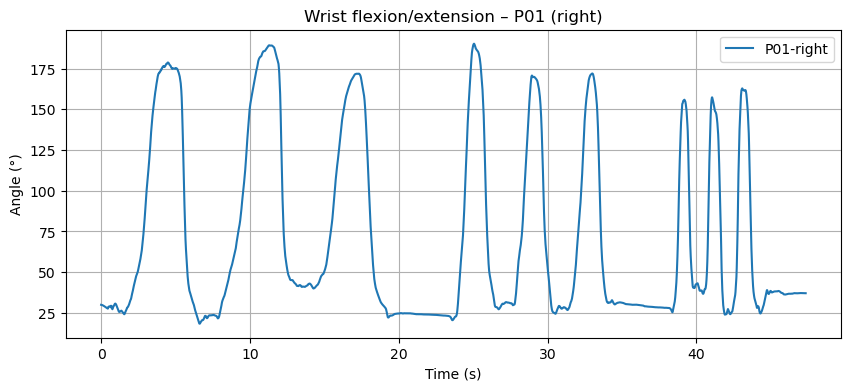

Angle range: 18.39° to 190.23°

===== P01 | LEFT =====


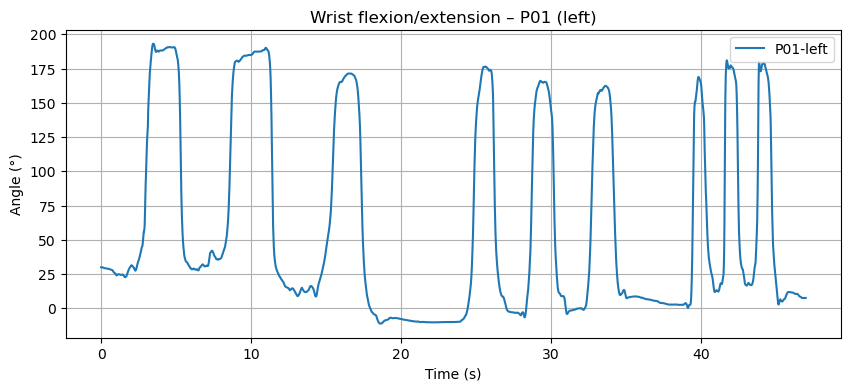

Angle range: -11.21° to 193.12°


In [22]:
# ==========================================================
# CONFIGURATION - PATIENT FILES
# ==========================================================
"""
Patient data configuration for passive elbow extension study.

Author: Anais Ragon + copilot 
Date: 21/04/2026
"""
import pandas as pd
import numpy as np
from io import StringIO
import os
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, savgol_filter
from scipy.ndimage import uniform_filter1d
import warnings
warnings.filterwarnings('ignore')

# ---------- PATIENT CONFIGURATION ----------
# Add your patients here following this structure
PATIENTS = {
    "P01": {
        "id": "Ch",
        "right": "Data_Ch_D.csv",
        "left": "Data_Ch_G.csv"
    

    },
    "P02": {
        "id": "Lo_1",
        "right": "Data_Lo_D_1.csv",
        "left": "Data_Lo_G_1.csv"
  
    },
    "P03": {
        "id": "Lo_2",
        "right": "Data_Lo_D_2.csv", 
        "left": "Data_Lo_G_2.csv"
    },
}

# Acquisition frequencies
FREQ_KPUSH = 1000  # Hz
FREQ_KMOVE = 250  # Hz

# ==========================================================
# LOAD FILE
# ==========================================================
def load_data(filename):

    candidate_dirs = [
        os.path.join("..", "data"),
        os.path.join(".", "data"),
        "."
    ]

    for base_dir in candidate_dirs:
        path = os.path.join(base_dir, filename)

        if os.path.exists(path):
            with open(path, "r", encoding="utf-8") as f:
                return f.readlines()

        if os.path.isdir(base_dir):
            matches = [f for f in os.listdir(base_dir) if f.lower() == filename.lower()]
            if matches:
                with open(os.path.join(base_dir, matches[0]), "r", encoding="utf-8") as f:
                    return f.readlines()

    raise FileNotFoundError(f"File not found: {filename}")


# ==========================================================
# PROCESS FILE
# ==========================================================
def process_file(filename):

    lines = load_data(filename)

    # ---------- FIND BLOCKS ----------
    idx_push, idx_move = None, None

    for i, line in enumerate(lines):
        if "K-Push" in line:
            idx_push = i
        if "K-Move" in line and idx_move is None:
            idx_move = i

    if idx_push < idx_move:
        push_lines = lines[idx_push:idx_move]
        move_lines = lines[idx_move:]
    else:
        push_lines = lines[idx_push:]
        move_lines = lines[idx_move:idx_push]

    # ---------- K-PUSH ----------
    header_idx_push = next(i for i, l in enumerate(push_lines) if "temps" in l)

    df_push = pd.read_csv(
        StringIO("".join(push_lines[header_idx_push:])),
        sep=r"\t|,",
        engine="python"
    ).dropna(axis=1, how='all')

    df_push = df_push.rename(columns={"temps (seconde)": "time", "CHANNEL_1": "force"})
    df_push = df_push[["time", "force"]].apply(pd.to_numeric, errors='coerce').dropna()

    # ---------- BASELINE ----------
    baseline = {"wrist": [], "shoulder": []}

    for line in move_lines:
        if "Quaternion de base" in line:

            parts = line.strip().split("\t")
            if len(parts) < 5:
                parts = line.strip().split(",")

            values = []
            for x in parts[1:]:
                try:
                    values.append(float(x))
                except:
                    continue

            values = values[:4]

            if "S121577" in parts[0]:
                baseline["wrist"] = values
            elif "S121578" in parts[0]:
                baseline["shoulder"] = values

    # ---------- MOVE DATA ----------
    header_idx_move = next(i for i, l in enumerate(move_lines) if "temps" in l)

    rows = []
    for line in move_lines[header_idx_move + 1:]:
        r = line.strip().split("\t")
        if len(r) < 2:
            r = line.strip().split(",")
        rows.append(r)

    df_move = pd.DataFrame(rows).dropna(axis=1, how='all')
    df_move = df_move.apply(pd.to_numeric, errors='coerce').ffill().bfill()

    # ---------- SENSORS ----------
    df_wrist = df_move.iloc[:, [0,1,2,3,4]].copy()
    df_wrist.columns = ["time","qx","qy","qz","qw"]

    df_shoulder = df_move.iloc[:, [0,6,7,8,9]].copy()
    df_shoulder.columns = ["time","qx","qy","qz","qw"]

    # ---------- DEBUG PRINT ----------
    print(f"\n===== FILE: {filename} =====")
    print("K-Push:\n", df_push.head())
    print("\nWrist:\n", df_wrist.head())
    print("\nShoulder:\n", df_shoulder.head())
    print("\nBaseline wrist:", baseline["wrist"])
    print("Baseline shoulder:", baseline["shoulder"])
    print("\nShapes:", df_push.shape, df_wrist.shape, df_shoulder.shape)

    return df_push, df_wrist, df_shoulder, baseline


# ==========================================================
# QUATERNION UTILS
# ==========================================================
def quat_conjugate(q):
    qx, qy, qz, qw = q
    return np.array([-qx, -qy, -qz, qw])

def quat_multiply(q1, q2):
    x1, y1, z1, w1 = q1
    x2, y2, z2, w2 = q2

    return np.array([
        w1*x2 + x1*w2 + y1*z2 - z1*y2,
        w1*y2 - x1*z2 + y1*w2 + z1*x2,
        w1*z2 + x1*y2 - y1*x2 + z1*w2,
        w1*w2 - x1*x2 - y1*y2 - z1*z2
    ])

def normalize_quat(q):
    return q / np.linalg.norm(q)


# ==========================================================
# ANGLE CALCULATION
# ==========================================================
def quaternion_to_angle_y_calibrated(df_quat, baseline_quat, baseline_deg):

    q_base = normalize_quat(np.array(baseline_quat))
    q_base_inv = quat_conjugate(q_base)

    angles = []

    for i in range(len(df_quat)):

        q = np.array([
            df_quat["qx"].iloc[i],
            df_quat["qy"].iloc[i],
            df_quat["qz"].iloc[i],
            df_quat["qw"].iloc[i]
        ])

        q = normalize_quat(q)

        q_corr = quat_multiply(q_base_inv, q)
        qx, qy, qz, qw = q_corr

        angle = np.arctan2(
            2*(qw*qy + qx*qz),
            1 - 2*(qy**2 + qz**2)
        )

        angles.append(angle)

    angles = np.unwrap(np.array(angles))
    angle_deg = np.degrees(angles)

    angle_zeroed = angle_deg - angle_deg[0]

    if np.mean(angle_zeroed) < 0:
        angle_zeroed = -angle_zeroed

    angle_anatomical = angle_zeroed + baseline_deg

    df = df_quat[["time"]].copy()
    df["angle"] = angle_anatomical

    return df


# ==========================================================
# CORRECTION - Multi-patients et bilatéral
# ==========================================================

results = {}

for patient_name, patient_data in PATIENTS.items():
    print(f"\n==============================")
    print(f"PATIENT: {patient_name} ({patient_data['id']})")
    print(f"==============================")

    results[patient_name] = {}

    # ✅ Corrigé : on traite droite ET gauche si présents
    for side in ["right", "left"]:
        if side not in patient_data:
            print(f"[INFO] No {side} file for {patient_name}")
            continue

        file = patient_data[side]

        try:
            df_push, df_wrist, df_shoulder, baseline = process_file(file)

            results[patient_name][side] = {
                "file": file,
                "push": df_push,
                "wrist": df_wrist,
                "shoulder": df_shoulder,
                "baseline": baseline
            }

            print(f"✅ Loaded: {file}")

        except FileNotFoundError as e:
            print(f"[WARNING] {e}")

# ==========================================================
# Processing + plotting (multi-patients, both sides)
# ==========================================================

all_angles_data = {}

for patient_name, patient_info in results.items():
    all_angles_data[patient_name] = {}

    for side, data in patient_info.items():
        print(f"\n===== {patient_name} | {side.upper()} =====")

        baseline_quat = data["baseline"]["wrist"]
        df_wrist = data["wrist"]

        if len(baseline_quat) != 4:
            print("⚠️ Missing baseline quaternion → skipped side.")
            continue

        df_angles = quaternion_to_angle_y_calibrated(
            df_wrist, baseline_quat, baseline_deg=30
        )

        all_angles_data[patient_name][side] = df_angles

        # ---------- Plot ----------
        plt.figure(figsize=(10, 4))
        plt.plot(df_angles["time"], df_angles["angle"],
                 label=f"{patient_name}-{side}")
        plt.xlabel("Time (s)")
        plt.ylabel("Angle (°)")
        plt.title(f"Wrist flexion/extension – {patient_name} ({side})")
        plt.grid(True)
        plt.legend()
        plt.show()

        print(f"Angle range: {df_angles['angle'].min():.2f}° to {df_angles['angle'].max():.2f}°")


=== DETECTION : P01 | RIGHT ===


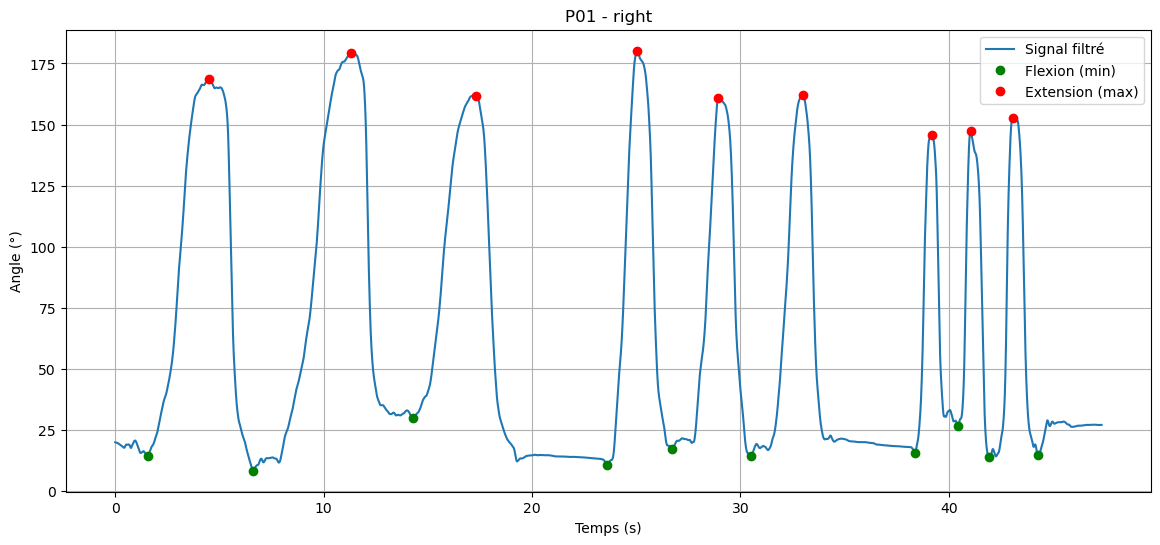


=== DETECTION : P01 | LEFT ===


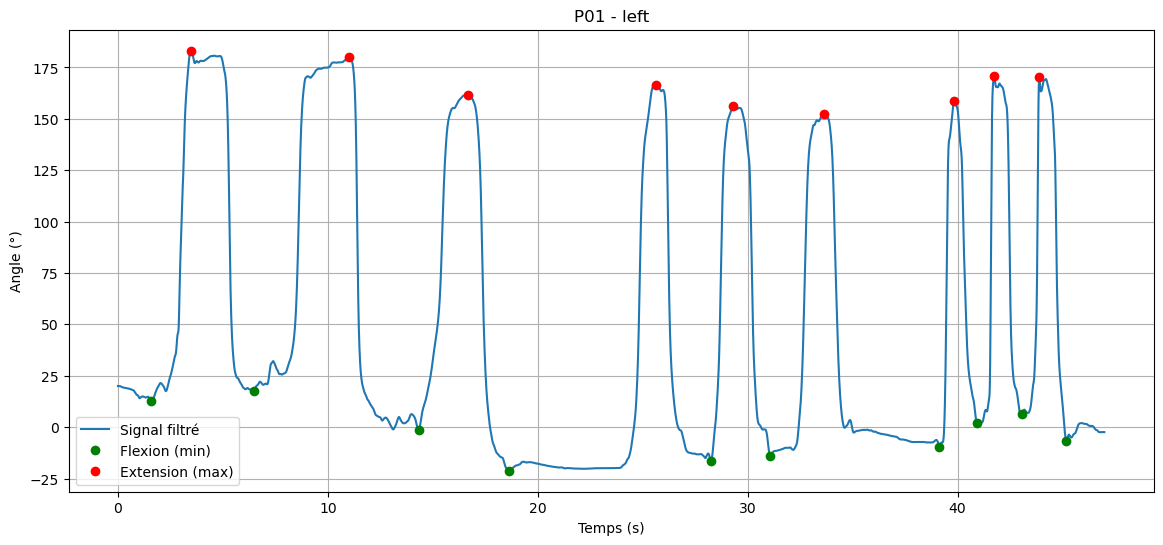


===== EVENTS: P01 | RIGHT =====
   event_id  t_start   t_end  duration   amplitude    velocity
0         1   1.5560   4.492    2.9360  154.475865   52.614395
1         2   6.6159  11.296    4.6801  170.893314   36.514885
2         3  14.2760  17.312    3.0360  131.851319   43.429288
3         4  23.6039  25.052    1.4481  169.695196  117.184722
4         5  26.7080  28.936    2.2280  143.397307   64.361448
5         6  30.5160  33.000    2.4840  147.501872   59.380786
6         7  38.3760  39.184    0.8080  130.482064  161.487703
7         8  40.4440  41.048    0.6040  120.594737  199.660161
8         9  41.9120  43.068    1.1560  138.832630  120.097431

===== EVENTS: P01 | LEFT =====
   event_id  t_start    t_end  duration   amplitude    velocity
0         1   1.5960   3.4800    1.8840  170.401217   90.446506
1         2   6.4760  10.9840    4.5080  162.395935   36.023943
2         3  14.3240  16.6640    2.3400  162.773344   69.561258
3         4  18.6159  25.6440    7.0281  187.5935

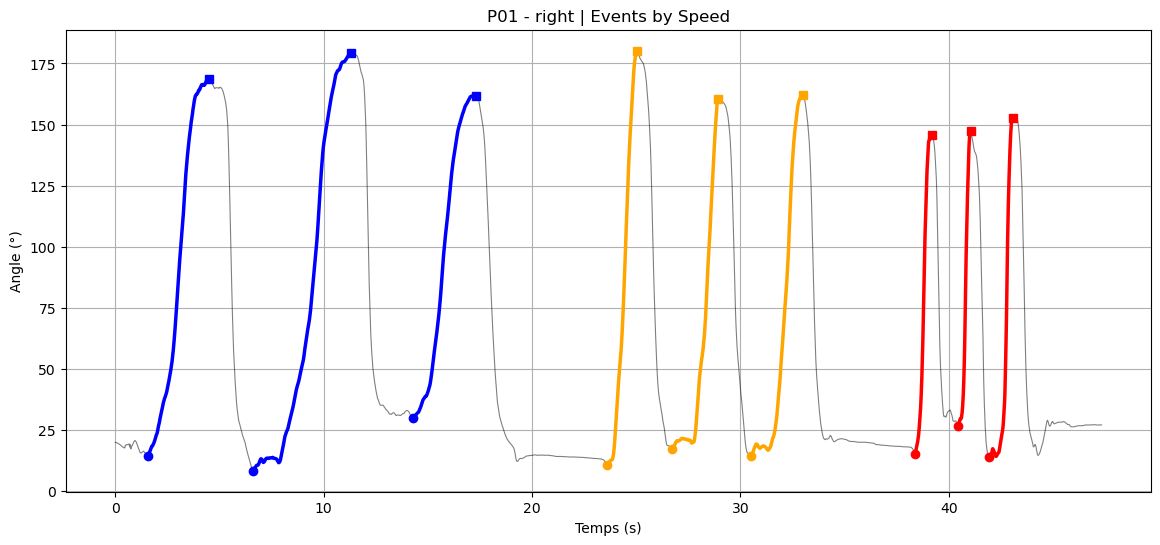


STATISTIQUES :

LENTE (n=3):
  Durée moyenne     : 3.55 s
  Amplitude moyenne : 152.4°
  Vitesse moyenne   : 44.2 °/s

MOYENNE (n=3):
  Durée moyenne     : 2.05 s
  Amplitude moyenne : 153.5°
  Vitesse moyenne   : 80.3 °/s

RAPIDE (n=3):
  Durée moyenne     : 0.86 s
  Amplitude moyenne : 130.0°
  Vitesse moyenne   : 160.4 °/s

===== EVENTS: P01 | LEFT =====

TABLE - P01 | left
 event_id speed_category  t_start   t_end  duration  amplitude   velocity
        1          lente   1.5960  3.4800    1.8840 170.401217  90.446506
        2          lente   6.4760 10.9840    4.5080 162.395935  36.023943
        3          lente  14.3240 16.6640    2.3400 162.773344  69.561258
        4        moyenne  18.6159 25.6440    7.0281 187.593545  26.691929
        5        moyenne  28.2519 29.3040    1.0521 172.604701 164.057315
        6        moyenne  31.0800 33.6280    2.5480 166.497435  65.344362
        7         rapide  39.1400 39.8480    0.7080 168.638220 238.189577
        8         rapide  4

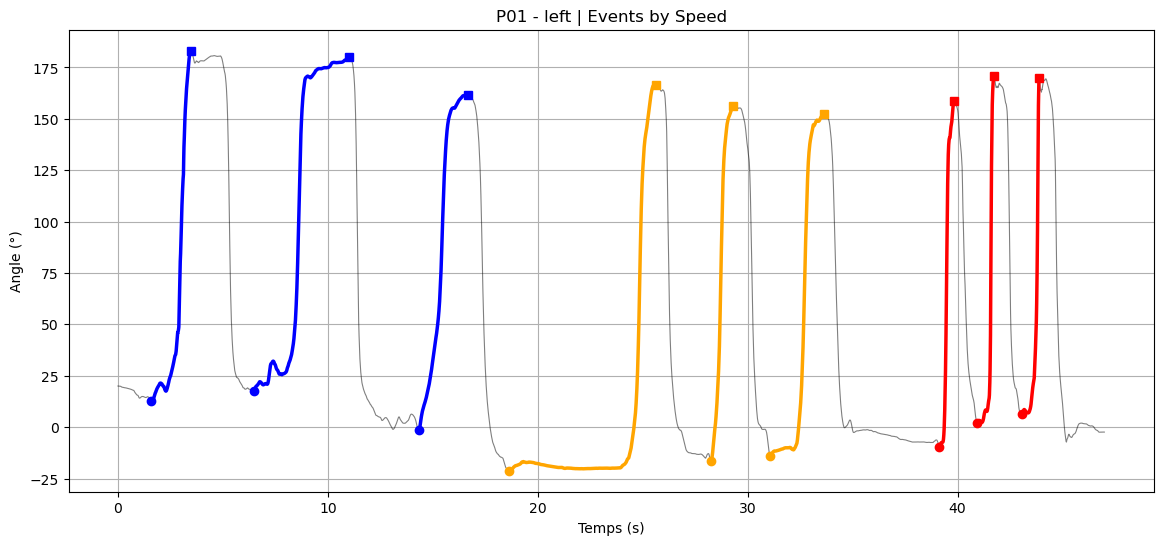


STATISTIQUES :

LENTE (n=3):
  Durée moyenne     : 2.91 s
  Amplitude moyenne : 165.2°
  Vitesse moyenne   : 65.3 °/s

MOYENNE (n=3):
  Durée moyenne     : 3.54 s
  Amplitude moyenne : 175.6°
  Vitesse moyenne   : 85.4 °/s

RAPIDE (n=3):
  Durée moyenne     : 0.78 s
  Amplitude moyenne : 166.9°
  Vitesse moyenne   : 215.1 °/s


In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks

# ==========================================================
# PARAMÈTRES
# ==========================================================
N_MAX = 9
N_MIN = 10
MIN_PROM = 15
MIN_DIST_SEC = 1.5
FILTER_CUTOFF = 10

# ==========================================================
# FILTRE
# ==========================================================
def butter_lowpass_filter(signal, cutoff, fs, order=4):
    nyq = 0.5 * fs
    normal_cut = min(cutoff / nyq, 0.99)
    b, a = butter(order, normal_cut, btype='low')
    return filtfilt(b, a, signal)

# ==========================================================
# DÉTECTION DES ÉVÉNEMENTS
# ==========================================================
def detect_clean_events(df_angles):

    time = df_angles["time"].values
    angle = df_angles["angle"].values
    fs = 1 / np.mean(np.diff(time))

    # ---------- FILTRAGE ----------
    signal_f = butter_lowpass_filter(angle, FILTER_CUTOFF, fs)

    # ---------- MAXIMA ----------
    dist_samples = int(fs * MIN_DIST_SEC)
    raw_max, _ = find_peaks(signal_f, distance=dist_samples, prominence=MIN_PROM)

    if len(raw_max) > N_MAX:
        idx = np.argsort(signal_f[raw_max])[::-1]
        raw_max = raw_max[idx[:N_MAX]]

    raw_max = np.sort(raw_max)

    # ---------- MINIMA ROBUSTES ----------
    minima = []

    # --- avant premier max ---
    if len(raw_max) > 0:
        first_max = raw_max[0]
        start = int(max(0, first_max - 3.5 * fs))
        segment = signal_f[start:first_max]

        if len(segment) > 5:
            minima.append(start + np.argmin(segment))

    # --- entre chaque max ---
    for i in range(len(raw_max) - 1):
        left = raw_max[i]
        right = raw_max[i + 1]

        segment = signal_f[left:right]
        if len(segment) > 5:
            minima.append(left + np.argmin(segment))

    # --- après dernier max ---
    if len(raw_max) > 0:
        last_max = raw_max[-1]
        segment = signal_f[last_max:]

        if len(segment) > 5:
            minima.append(last_max + np.argmin(segment))

    minima = np.array(minima, dtype=int)

    # ---------- GARANTIES ----------
    minima = np.unique(minima)

    if len(minima) > N_MIN:
        minima = minima[:N_MIN]
    elif len(minima) < N_MIN and len(minima) > 0:
        minima = np.pad(minima, (0, N_MIN - len(minima)), mode='edge')

    return minima, raw_max, signal_f

# ==========================================================
# PLOT + STOCKAGE
# ==========================================================
def plot_and_store(df_angles, minima, maxima, signal_f, patient_name, side, events_results):

    events_results.setdefault(patient_name, {})

    events_results[patient_name][side] = {
        "angles": df_angles,
        "signal_filtered": signal_f,
        "peaks_flexion": minima,
        "peaks_extension": maxima
    }

    time = df_angles["time"].values

    plt.figure(figsize=(14, 6))
    plt.plot(time, signal_f, label="Signal filtré")

    if len(minima) > 0:
        plt.plot(time[minima], signal_f[minima], "go", label="Flexion (min)")

    if len(maxima) > 0:
        plt.plot(time[maxima], signal_f[maxima], "ro", label="Extension (max)")

    plt.title(f"{patient_name} - {side}")
    plt.xlabel("Temps (s)")
    plt.ylabel("Angle (°)")
    plt.legend()
    plt.grid()
    plt.show()

# ==========================================================
# DÉTECTION MULTI-PATIENTS
# ==========================================================
events_results = {}

for patient_name, pdata in results.items():
    for side, data in pdata.items():

        print(f"\n=== DETECTION : {patient_name} | {side.upper()} ===")

        df = data["wrist"]
        baseline = data["baseline"]["wrist"]

        df_angles = quaternion_to_angle_y_calibrated(df, baseline, baseline_deg=20)

        minima, maxima, signal_f = detect_clean_events(df_angles)

        plot_and_store(df_angles, minima, maxima, signal_f,
                       patient_name, side, events_results)

# ==========================================================
# ANALYSE DES ÉVÉNEMENTS
# ==========================================================
all_events_summary = {}

for patient_name in events_results:

    all_events_summary[patient_name] = {}

    for side in events_results[patient_name]:

        print(f"\n===== EVENTS: {patient_name} | {side.upper()} =====")

        data = events_results[patient_name][side]

        df_angles = data["angles"]
        peaks_flexion = data["peaks_flexion"]
        peaks_extension = data["peaks_extension"]

        signal = df_angles["angle"].values
        time = df_angles["time"].values

        events = []

        n_events = min(len(peaks_extension), len(peaks_flexion) - 1)

        for i in range(n_events):

            min_idx = peaks_flexion[i]
            max_idx = peaks_extension[i]

            t_start = time[min_idx]
            t_end = time[max_idx]

            duration = t_end - t_start
            amplitude = signal[max_idx] - signal[min_idx]
            velocity = amplitude / duration if duration > 0 else 0

            events.append({
                "event_id": i + 1,
                "t_start": t_start,
                "t_end": t_end,
                "duration": duration,
                "amplitude": amplitude,
                "velocity": velocity
            })

        df_events = pd.DataFrame(events)
        all_events_summary[patient_name][side] = df_events

        print(df_events)

# ==========================================================
# EVENTS ANALYSIS (MULTI-PATIENTS)
# ==========================================================
all_events_summary = {}

for patient_name in events_results:

    all_events_summary[patient_name] = {}

    for side in events_results[patient_name]:

        print(f"\n===== EVENTS: {patient_name} | {side.upper()} =====")

        data = events_results[patient_name][side]

        df_angles = data["angles"]
        peaks_flexion = data["peaks_flexion"]
        peaks_extension = data["peaks_extension"]

        signal = df_angles["angle"].values
        time = df_angles["time"].values

        # ---------- 1. EVENTS ----------
        events = []

        if len(peaks_flexion) < 2 or len(peaks_extension) == 0:
            print("⚠️ Pas assez de pics pour créer des événements")
            continue

        n_events = min(len(peaks_extension), len(peaks_flexion) - 1)

        for i in range(n_events):

            min_idx = peaks_flexion[i]
            max_idx = peaks_extension[i]

            t_start = time[min_idx]
            t_end = time[max_idx]
            duration = t_end - t_start

            angle_start = signal[min_idx]
            angle_end = signal[max_idx]
            amplitude = angle_end - angle_start

            velocity = amplitude / duration if duration > 0 else 0

            events.append({
                'event_id': i + 1,
                'min_idx': min_idx,
                'max_idx': max_idx,
                't_start': t_start,
                't_end': t_end,
                'duration': duration,
                'angle_start': angle_start,
                'angle_end': angle_end,
                'amplitude': amplitude,
                'velocity': velocity
            })

        # ---------- 2. CLASSIFICATION ----------
        speed_labels = ['lente'] * 3 + ['moyenne'] * 3 + ['rapide'] * 3

        for i, event in enumerate(events):
            event['speed_category'] = speed_labels[i] if i < len(speed_labels) else 'extra'

        df_events = pd.DataFrame(events)

        all_events_summary[patient_name][side] = df_events

        # ---------- 3. TABLE ----------
        print("\n" + "="*60)
        print(f"TABLE - {patient_name} | {side}")
        print("="*60)

        if not df_events.empty:
            print(df_events[['event_id', 'speed_category',
                             't_start', 't_end',
                             'duration', 'amplitude', 'velocity']].to_string(index=False))
        else:
            print("Aucun événement détecté")

        # ---------- 4. PLOT ----------
        colors_speed = {
            'lente': 'blue',
            'moyenne': 'orange',
            'rapide': 'red',
            'extra': 'gray'
        }

        plt.figure(figsize=(14,6))
        plt.plot(time, signal, 'k-', linewidth=0.8, alpha=0.5)

        for event in events:
            color = colors_speed[event['speed_category']]

            idx_range = np.arange(event['min_idx'], event['max_idx'] + 1)

            plt.plot(time[idx_range], signal[idx_range],
                     color=color, linewidth=2.5)

            plt.plot(time[event['min_idx']], signal[event['min_idx']],
                     'o', color=color)

            plt.plot(time[event['max_idx']], signal[event['max_idx']],
                     's', color=color)

        plt.title(f"{patient_name} - {side} | Events by Speed")
        plt.xlabel("Temps (s)")
        plt.ylabel("Angle (°)")
        plt.grid(True)
        plt.show()

        # ---------- 5. STATS ----------
        print("\nSTATISTIQUES :")

        for cat in ['lente', 'moyenne', 'rapide']:
            subset = df_events[df_events['speed_category'] == cat]

            if len(subset) == 0:
                continue

            print(f"\n{cat.upper()} (n={len(subset)}):")
            print(f"  Durée moyenne     : {subset['duration'].mean():.2f} s")
            print(f"  Amplitude moyenne : {subset['amplitude'].mean():.1f}°")
            print(f"  Vitesse moyenne   : {subset['velocity'].mean():.1f} °/s")

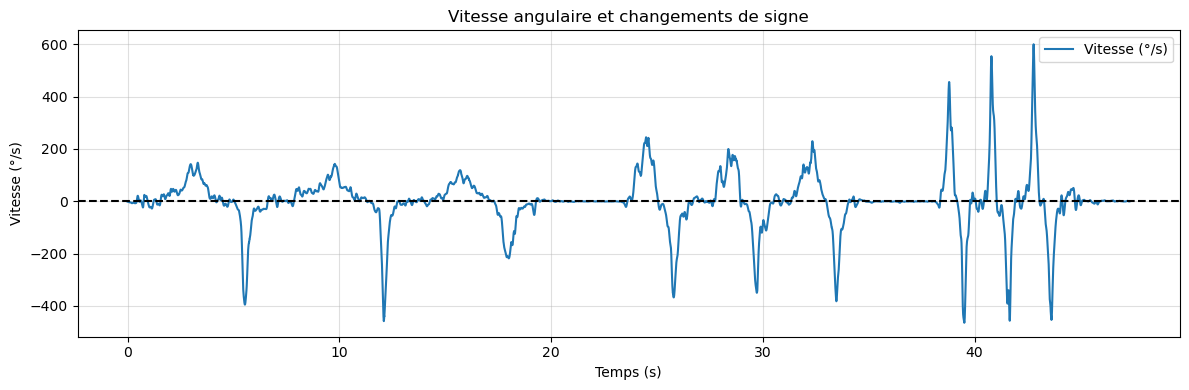

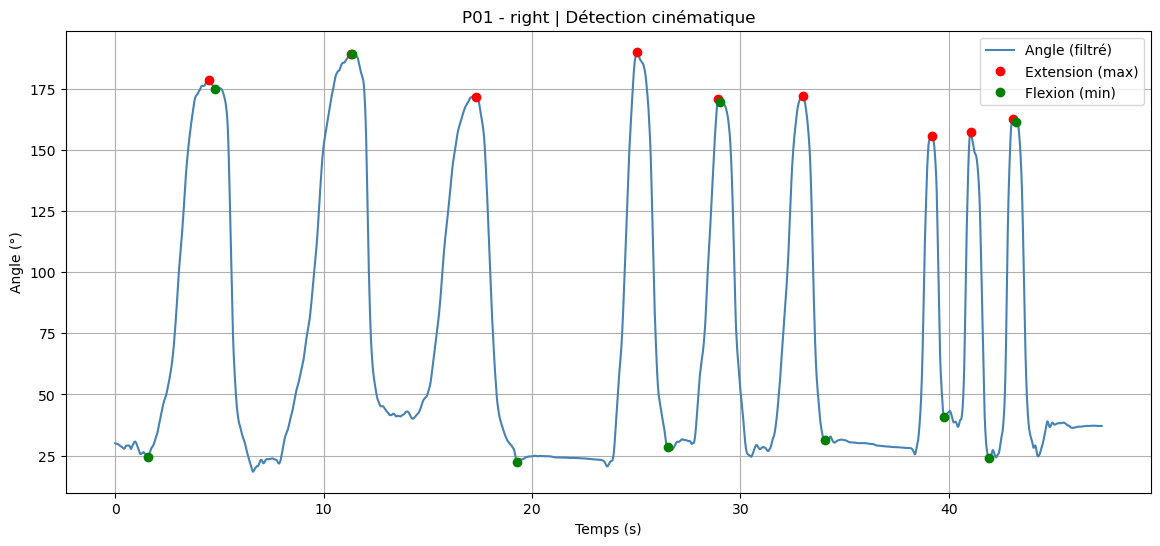

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks

# ==========================================================
# PARAMÈTRES
# ==========================================================
N_MAX = 9
N_MIN = 10
MIN_PROM = 15
MIN_DIST_SEC = 1.5
FILTER_CUTOFF = 10

# ==========================================================
# FILTRE
# ==========================================================
def butter_lowpass_filter(signal, cutoff, fs, order=4):
    nyq = 0.5 * fs
    normal_cut = min(cutoff / nyq, 0.99)
    b, a = butter(order, normal_cut, btype='low')
    return filtfilt(b, a, signal)



# ==========================================================
# DÉTECTION DES ÉVÉNEMENTS (version cinématique corrigée)
# ==========================================================
def detect_clean_events(df_angles):
    """
    Détection cinématique :
    - Maxima = pics d’extension
    - Minima = premier point où la vitesse change de signe (début de la flexion)
      après chaque maximum.
    """

    time = df_angles["time"].values
    angle = df_angles["angle"].values
    fs = 1 / np.mean(np.diff(time))

    # ---------- FILTRAGE ----------
    signal_f = butter_lowpass_filter(angle, FILTER_CUTOFF, fs)

    # ---------- CALCUL DE LA VITESSE ----------
    velocity = np.gradient(signal_f, time)  # ✅ correction ici

    # ---------- DÉTECTION DES MAXIMA (extrema d’extension) ----------
    dist_samples = int(fs * MIN_DIST_SEC)
    raw_max, _ = find_peaks(signal_f, distance=dist_samples, prominence=MIN_PROM)
    raw_max = np.sort(raw_max)

    minima = []

    # ---------- DÉTECTION DES MINIMA : changement de signe de la vitesse ----------
    for max_idx in raw_max:
        # Portion du signal après chaque maximum
        v_post = velocity[max_idx:]
        if len(v_post) < 3:
            continue

        # Indices où le signe de la vitesse passe de négatif à positif
        change = np.where(np.diff(np.sign(v_post)) > 0)[0]

        if len(change) > 0:
            c = change[0]
            # Prend le minimum d’angle jusqu’à ce changement
            seg = signal_f[max_idx : max_idx + c + 1]
            if len(seg) > 3:
                min_idx = max_idx + np.argmin(seg)
                minima.append(min_idx)
        else:
            # En secours : chercher un minimum local après le pic
            next_min, _ = find_peaks(-signal_f[max_idx:], distance=int(fs * 0.6))
            if len(next_min) > 0:
                minima.append(max_idx + next_min[0])

    # ---------- PREMIER MINIMUM AVANT LE PREMIER MAX ----------
    if len(raw_max) > 0:
        pre_seg = signal_f[: raw_max[0]]
        if len(pre_seg) > 5:
            minima.insert(0, np.argmin(pre_seg))

    minima = np.unique(np.array(minima, dtype=int))

    # ---------- GARANTIES ----------
    if len(minima) > N_MIN:
        minima = minima[:N_MIN]
    elif len(minima) < N_MIN and len(minima) > 0:
        minima = np.pad(minima, (0, N_MIN - len(minima)), mode="edge")

    return minima, raw_max, signal_f


# ==========================================================
# VISUALISATION DE LA VITESSE pour diagnostic
# ==========================================================
def plot_velocity_diagnostics(df_angles):
    time = df_angles["time"].values
    angle = df_angles["angle"].values
    fs = 1 / np.mean(np.diff(time))
    signal_f = butter_lowpass_filter(angle, FILTER_CUTOFF, fs)
    velocity = np.gradient(signal_f, time)

    plt.figure(figsize=(12, 4))
    plt.plot(time, velocity, label="Vitesse (°/s)")
    plt.axhline(0, color="k", linestyle="--")
    plt.title("Vitesse angulaire et changements de signe")
    plt.xlabel("Temps (s)")
    plt.ylabel("Vitesse (°/s)")
    plt.grid(True, alpha=0.4)
    plt.legend()
    plt.tight_layout()
    plt.show()


# ==========================================================
# TEST SUR UN PATIENT / CÔTÉ EXISTANT POUR AFFICHAGE
# ==========================================================

# ⚠️ Choisis un patient et un côté présents dans ta structure "all_angles_data"
patient = "P01"
side = "right"

if patient in all_angles_data and side in all_angles_data[patient]:
    # Récupère les angles
    df_angles = all_angles_data[patient][side]

    # --- 1. Calcul des extrema
    minima, maxima, signal_f = detect_clean_events(df_angles)

    # --- 2. Diagnostic vitesse ---
    plot_velocity_diagnostics(df_angles)

    # --- 3. Plot principal des événements ---
    time = df_angles["time"].values

    plt.figure(figsize=(14, 6))
    plt.plot(time, signal_f, label="Angle (filtré)", color="steelblue")
    plt.plot(time[maxima], signal_f[maxima], "ro", label="Extension (max)")
    plt.plot(time[minima], signal_f[minima], "go", label="Flexion (min)")
    plt.title(f"{patient} - {side} | Détection cinématique")
    plt.xlabel("Temps (s)")
    plt.ylabel("Angle (°)")
    plt.legend()
    plt.grid(True)
    plt.show()

else:
    print(f"Aucune donnée trouvée pour {patient} {side} dans all_angles_data.")




=== DETECTION : P01 | RIGHT ===


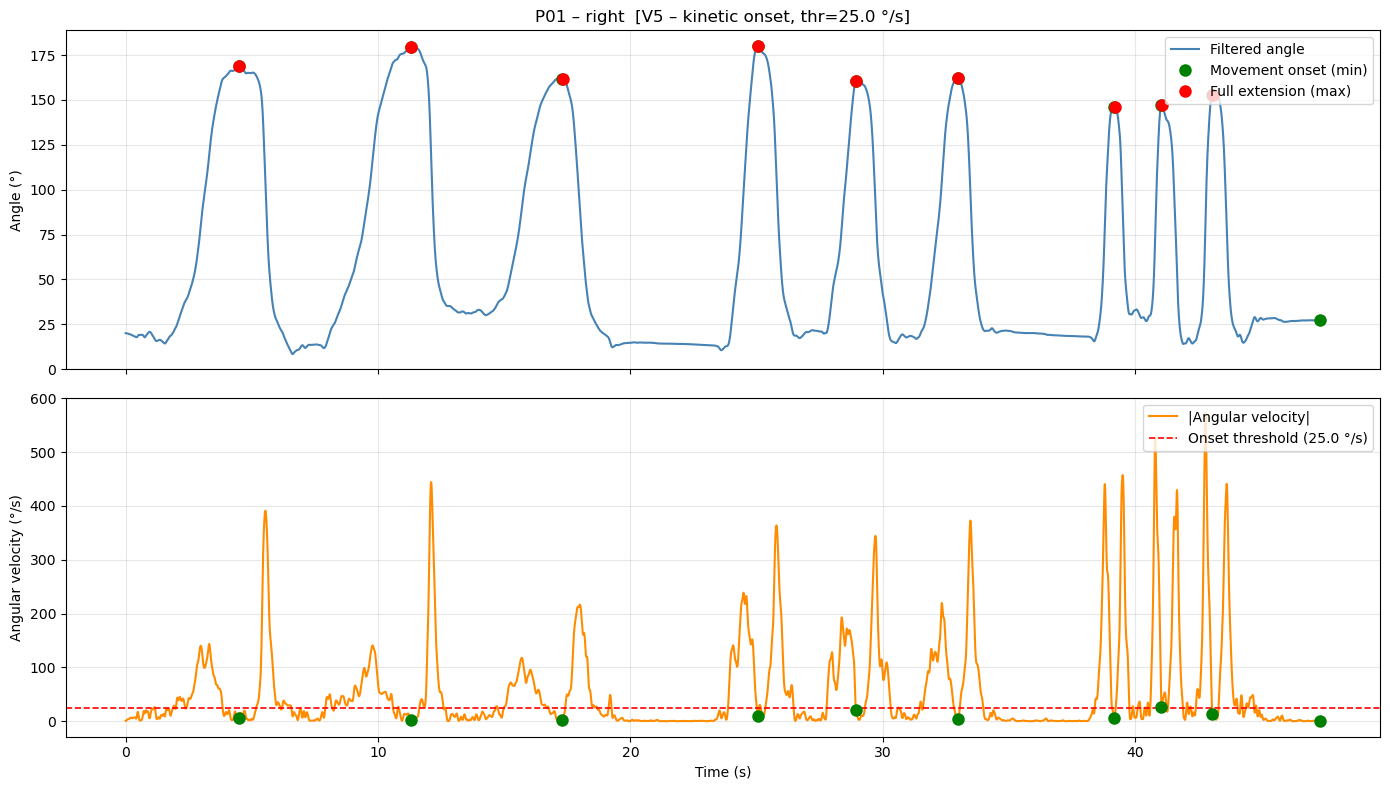


=== DETECTION : P01 | LEFT ===


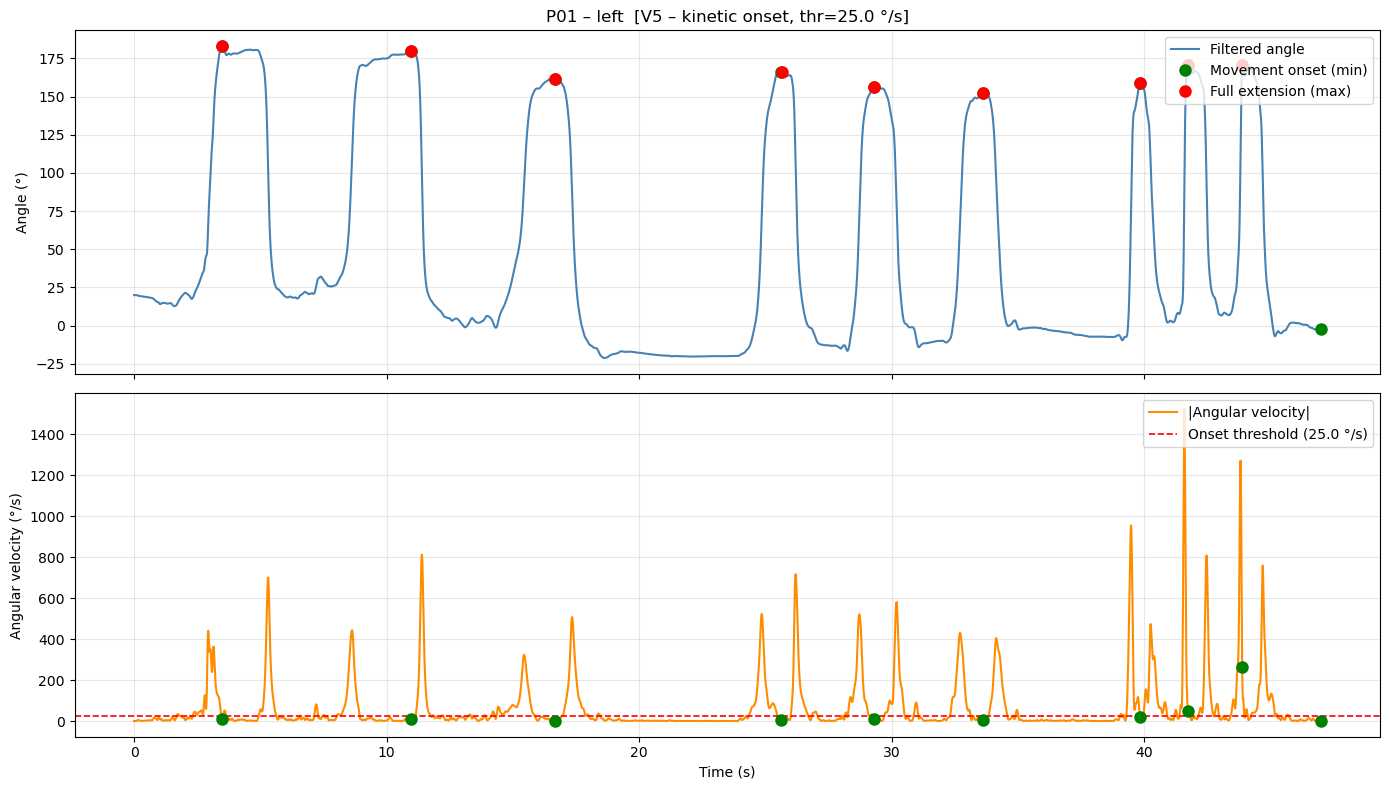


===== EVENTS: P01 | RIGHT =====

TABLE – P01 | right
 event_id speed_category  t_start  t_end  duration  amplitude  velocity
        1          lente    4.488  4.492     0.004  -0.010161 -2.540323
        2          lente   11.292 11.296     0.004   0.010387  2.596714
        3          lente   17.308 17.312     0.004   0.003961  0.990365
        4        moyenne   25.048 25.052     0.004   0.019625  4.906206
        5        moyenne   28.932 28.936     0.004   0.053431 13.357660
        6        moyenne   32.996 33.000     0.004   0.000009  0.002218
        7         rapide   39.180 39.184     0.004  -0.008447 -2.111727
        8         rapide   41.044 41.048     0.004   0.004962  1.240537
        9         rapide   43.064 43.068     0.004   0.035681  8.920194


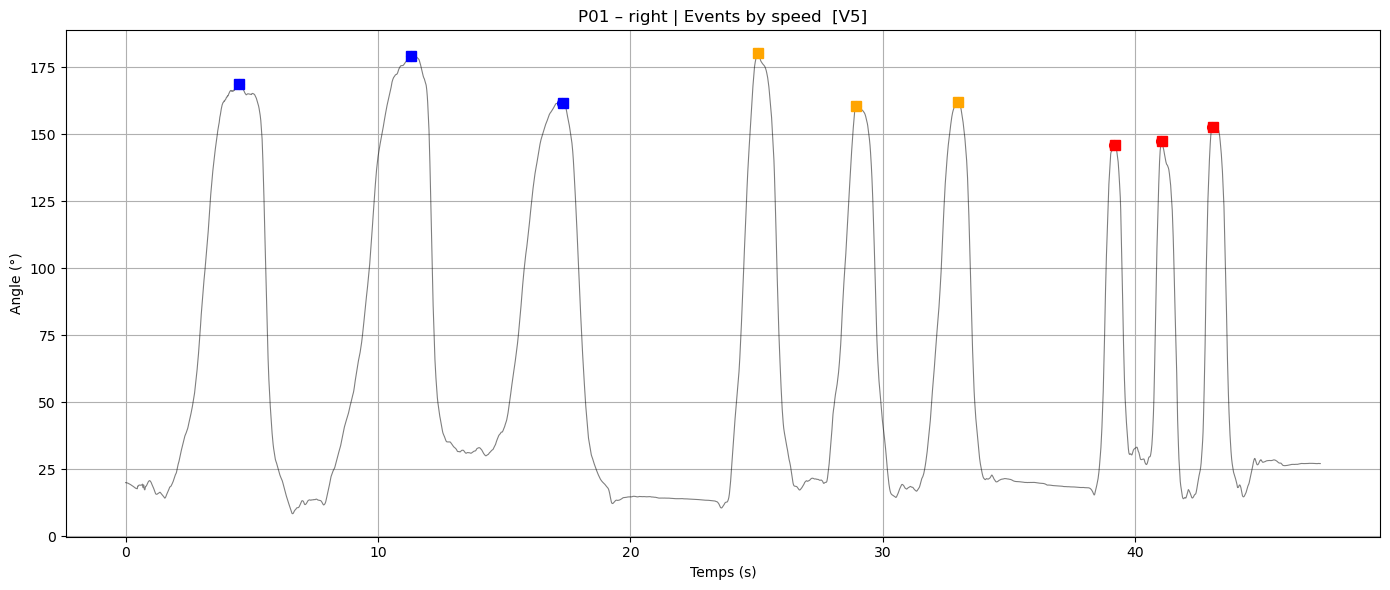


STATISTIQUES :

LENTE (n=3):
  Durée moyenne     : 0.00 s
  Amplitude moyenne : 0.0°
  Vitesse moyenne   : 0.3 °/s

MOYENNE (n=3):
  Durée moyenne     : 0.00 s
  Amplitude moyenne : 0.0°
  Vitesse moyenne   : 6.1 °/s

RAPIDE (n=3):
  Durée moyenne     : 0.00 s
  Amplitude moyenne : 0.0°
  Vitesse moyenne   : 2.7 °/s

===== EVENTS: P01 | LEFT =====

TABLE – P01 | left
 event_id speed_category  t_start   t_end  duration  amplitude   velocity
        1          lente    3.476  3.4800    0.0040  -0.033733  -8.433238
        2          lente   10.980 10.9840    0.0040   0.009664   2.415885
        3          lente   16.660 16.6640    0.0040  -0.003326  -0.831434
        4        moyenne   25.640 25.6440    0.0040  -0.002150  -0.537433
        5        moyenne   29.300 29.3040    0.0040   0.001667   0.416868
        6        moyenne   33.624 33.6280    0.0040  -0.004737  -1.184232
        7         rapide   39.844 39.8480    0.0040   0.002639   0.659874
        8         rapide   41.736 41.

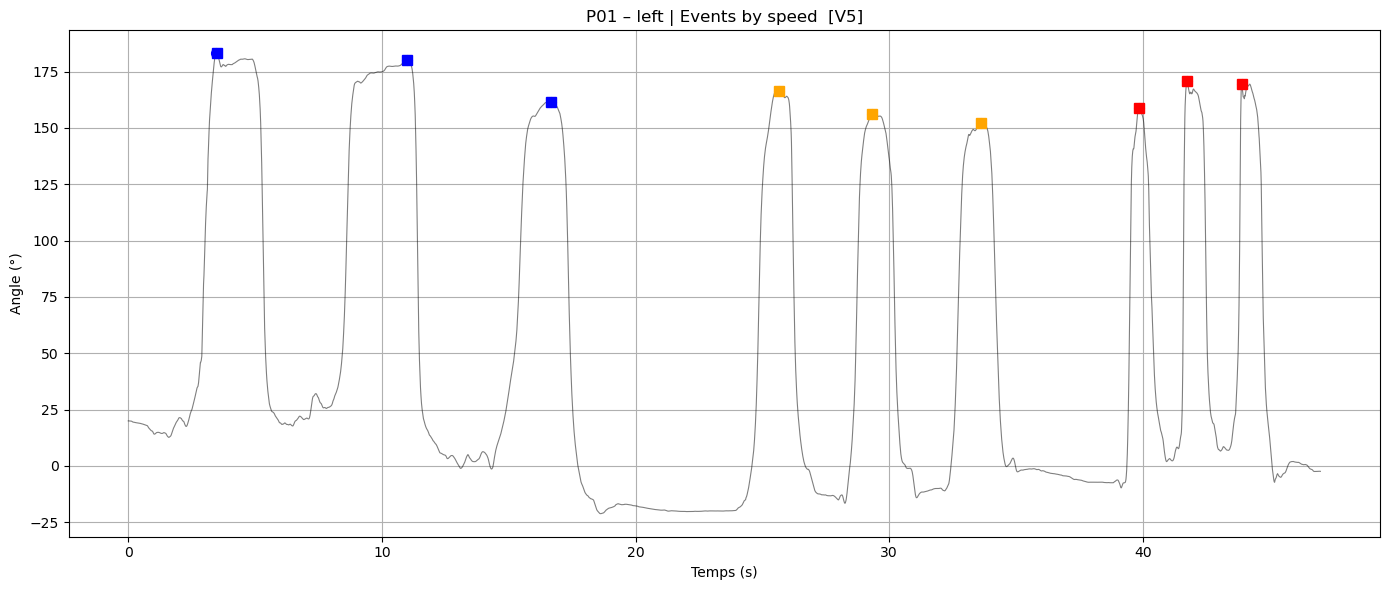


STATISTIQUES :

LENTE (n=3):
  Durée moyenne     : 0.00 s
  Amplitude moyenne : -0.0°
  Vitesse moyenne   : -2.3 °/s

MOYENNE (n=3):
  Durée moyenne     : 0.00 s
  Amplitude moyenne : -0.0°
  Vitesse moyenne   : -0.4 °/s

RAPIDE (n=3):
  Durée moyenne     : 0.00 s
  Amplitude moyenne : -0.0°
  Vitesse moyenne   : -12.1 °/s


In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks

# ==========================================================
# PARAMETERS
# ==========================================================
N_MAX                  = 9
N_MIN                  = 10
MIN_PROM               = 15
MIN_DIST_SEC           = 1.5
FILTER_CUTOFF          = 10

# --- V5: kinetic onset criterion ---
VELOCITY_ONSET_THRESH  = 25.0   # °/s – the descent after a peak must drop
                                 # below this threshold to define the new onset.
                                 # Adjust between 10 and 30 depending on your data.
VELOCITY_SMOOTH_WINDOW = 15     # samples – Savitzky-Golay window for velocity
                                 # smoothing before thresholding (odd integer).

# ==========================================================
# LOW-PASS FILTER
# ==========================================================
def butter_lowpass_filter(signal, cutoff, fs, order=4):
    """Apply a zero-phase Butterworth low-pass filter to the signal."""
    nyq        = 0.5 * fs
    normal_cut = min(cutoff / nyq, 0.99)
    b, a       = butter(order, normal_cut, btype='low')
    return filtfilt(b, a, signal)

# ==========================================================
# SMOOTH VELOCITY COMPUTATION
# ==========================================================
def compute_velocity(signal_f, fs, window=VELOCITY_SMOOTH_WINDOW):
    """
    Compute the smoothed absolute angular velocity of the signal.

    Uses a central-difference gradient (np.gradient) followed by a
    uniform moving-average smoothing over `window` samples to reduce
    noise before applying the kinetic threshold.

    Parameters
    ----------
    signal_f : np.ndarray – filtered angle signal (°)
    fs       : float      – sampling frequency (Hz)
    window   : int        – smoothing window length (samples)

    Returns
    -------
    velocity : np.ndarray – smoothed absolute angular velocity (°/s),
                            same length as signal_f
    """
    raw_vel  = np.gradient(signal_f, 1.0 / fs)          # °/s, central diff
    # Uniform moving average to reduce IMU noise
    kernel   = np.ones(window) / window
    velocity = np.convolve(np.abs(raw_vel), kernel, mode='same')
    return velocity

# ==========================================================
# KINETIC ONSET DETECTION  (core V5 function)
# ==========================================================
def find_kinetic_onset(signal_f, velocity, peak_idx, prev_peak_idx=None):
    """
    Find the movement onset AFTER a maximum using a kinetic criterion.

    Rationale
    ---------
    After each extension peak, the elbow returns toward flexion: angular
    velocity increases, then decreases again as the limb decelerates and
    reaches the next resting position (pause).  The true onset of the
    NEXT movement cycle corresponds to the moment where velocity starts
    rising again from a low value.

    Algorithm (backward search from next peak)
    ------------------------------------------
    Given the inter-peak window [peak_idx : next_peak_idx]:
      1. Compute the smoothed velocity in that window.
      2. Search BACKWARDS from the next peak.
      3. The onset is the last sample where velocity was still below
         VELOCITY_ONSET_THRESH — i.e. the first sample of the rising
         velocity that characterises the start of the next movement.
      4. The corresponding angle sample is returned as the minimum.

    Why this avoids pause artefacts
    --------------------------------
    During the ~5 s pause, velocity stays near 0 (well below the
    threshold).  The backward search therefore skips the entire pause
    and lands on the sample just before velocity rises due to the
    actual movement — regardless of how long the pause is.

    Parameters
    ----------
    signal_f      : np.ndarray – filtered angle signal (°)
    velocity      : np.ndarray – smoothed absolute velocity (°/s)
    peak_idx      : int        – index of the current maximum
    prev_peak_idx : int|None   – index of the previous maximum (unused
                                 here, kept for API symmetry)

    Returns
    -------
    int : absolute sample index of the detected onset
          (= the angle minimum closest to the true movement start)
    """
    search_start = peak_idx
    search_end   = len(signal_f)

    vel_segment  = velocity[search_start:search_end]

    # Backward scan: find last sample below threshold
    onset_local  = 0   # default fallback = start of window
    for j in range(len(vel_segment) - 1, -1, -1):
        if vel_segment[j] < VELOCITY_ONSET_THRESH:
            onset_local = j
            break

    return search_start + onset_local

# ==========================================================
# EVENT DETECTION  –  V5 : KINETIC ONSET
# ==========================================================
def detect_clean_events(df_angles):
    """
    Detect extension maxima and kinetic-onset minima.

    Strategy (V5):
      1. Filter the signal (Butterworth low-pass, FILTER_CUTOFF Hz).
      2. Compute the smoothed absolute angular velocity.
      3. Detect extension maxima with find_peaks (prominence + distance).
      4. For each maximum, the preceding onset is found by scanning
         the velocity in the window AFTER the previous maximum:
         the onset = last sample where velocity < VELOCITY_ONSET_THRESH,
         found by a backward search from the current maximum.
         → This is purely kinetic: no anatomical angle threshold,
           no fixed time window, fully robust to any pause duration.

    Parameters
    ----------
    df_angles : pd.DataFrame – columns 'time' (s) and 'angle' (°).

    Returns
    -------
    minima   : np.ndarray – indices of detected movement onsets
    raw_max  : np.ndarray – indices of full-extension peaks
    signal_f : np.ndarray – filtered angle signal
    velocity : np.ndarray – smoothed velocity (for optional plotting)
    """
    time    = df_angles["time"].values
    angle   = df_angles["angle"].values
    fs      = 1.0 / np.mean(np.diff(time))

    # Step 1 – filter
    signal_f = butter_lowpass_filter(angle, FILTER_CUTOFF, fs)

    # Step 2 – velocity
    velocity = compute_velocity(signal_f, fs)

    # Step 3 – maxima
    dist_samples = int(fs * MIN_DIST_SEC)
    raw_max, _   = find_peaks(signal_f,
                               distance=dist_samples,
                               prominence=MIN_PROM)
    if len(raw_max) > N_MAX:
        idx     = np.argsort(signal_f[raw_max])[::-1]
        raw_max = raw_max[idx[:N_MAX]]
    raw_max = np.sort(raw_max)

    # Step 4 – kinetic onsets
    minima = []

    for i, peak_idx in enumerate(raw_max):

        if i == 0:
            # First peak: search from the beginning of the signal
            # Use backward scan on velocity before the first peak
            vel_segment  = velocity[0:peak_idx]
            onset_local  = 0
            for j in range(len(vel_segment) - 1, -1, -1):
                if vel_segment[j] < VELOCITY_ONSET_THRESH:
                    onset_local = j
                    break
            minima.append(onset_local)

        else:
            # Subsequent peaks: search in the window after the previous peak
            prev_peak = raw_max[i - 1]
            onset     = find_kinetic_onset(signal_f, velocity,
                                           prev_peak, None)
            # The onset index is clipped so it stays before the current peak
            onset = min(onset, peak_idx - 1)
            minima.append(onset)

    # Onset after the last peak (for completeness / last flexion)
    if len(raw_max) > 0:
        last_peak   = raw_max[-1]
        vel_segment = velocity[last_peak:]
        onset_local = 0
        for j in range(len(vel_segment) - 1, -1, -1):
            if vel_segment[j] < VELOCITY_ONSET_THRESH:
                onset_local = j
                break
        minima.append(last_peak + onset_local)

    minima = np.array(minima, dtype=int)
    minima = np.unique(minima)

    if len(minima) > N_MIN:
        minima = minima[:N_MIN]
    elif 0 < len(minima) < N_MIN:
        minima = np.pad(minima, (0, N_MIN - len(minima)), mode='edge')

    return minima, raw_max, signal_f, velocity

# ==========================================================
# PLOT + STORE  (with velocity subplot for verification)
# ==========================================================
def plot_and_store(df_angles, minima, maxima, signal_f, velocity,
                   patient_name, side, events_results):
    """
    Store detection results and display:
      - Top panel : filtered angle with detected onsets (green) and peaks (red)
      - Bottom panel: smoothed velocity with the kinetic threshold line
        → allows visual verification that onsets are correctly placed
    """
    events_results.setdefault(patient_name, {})
    events_results[patient_name][side] = {
        "angles"          : df_angles,
        "signal_filtered" : signal_f,
        "peaks_flexion"   : minima,
        "peaks_extension" : maxima,
        "velocity"        : velocity
    }

    time = df_angles["time"].values

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

    # --- Angle ---
    ax1.plot(time, signal_f, color='steelblue', label='Filtered angle')
    if len(minima) > 0:
        ax1.plot(time[minima], signal_f[minima], 'go',
                 ms=8, zorder=3, label='Movement onset (min)')
    if len(maxima) > 0:
        ax1.plot(time[maxima], signal_f[maxima], 'ro',
                 ms=8, zorder=3, label='Full extension (max)')
    ax1.set_ylabel('Angle (°)')
    ax1.set_title(f'{patient_name} – {side}  '
                  f'[V5 – kinetic onset, thr={VELOCITY_ONSET_THRESH} °/s]')
    ax1.legend(loc='upper right')
    ax1.grid(True, alpha=0.3)

    # --- Velocity ---
    ax2.plot(time, velocity, color='darkorange', label='|Angular velocity|')
    ax2.axhline(y=VELOCITY_ONSET_THRESH, color='red',
                linestyle='--', linewidth=1.2,
                label=f'Onset threshold ({VELOCITY_ONSET_THRESH} °/s)')
    if len(minima) > 0:
        ax2.plot(time[minima], velocity[minima], 'go', ms=8, zorder=3)
    ax2.set_ylabel('Angular velocity (°/s)')
    ax2.set_xlabel('Time (s)')
    ax2.legend(loc='upper right')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# ==========================================================
# MULTI-PATIENT DETECTION LOOP
# ==========================================================
events_results = {}

for patient_name, pdata in results.items():
    for side, data in pdata.items():

        print(f"\n=== DETECTION : {patient_name} | {side.upper()} ===")

        df       = data["wrist"]
        baseline = data["baseline"]["wrist"]

        df_angles = quaternion_to_angle_y_calibrated(df, baseline, baseline_deg=20)

        minima, maxima, signal_f, velocity = detect_clean_events(df_angles)

        plot_and_store(df_angles, minima, maxima, signal_f, velocity,
                       patient_name, side, events_results)

# ==========================================================
# EVENTS ANALYSIS
# ==========================================================
all_events_summary = {}

for patient_name in events_results:
    all_events_summary[patient_name] = {}

    for side in events_results[patient_name]:

        print(f"\n===== EVENTS: {patient_name} | {side.upper()} =====")

        data            = events_results[patient_name][side]
        df_angles       = data["angles"]
        peaks_flexion   = data["peaks_flexion"]
        peaks_extension = data["peaks_extension"]
        signal          = df_angles["angle"].values
        time            = df_angles["time"].values

        events = []

        if len(peaks_flexion) < 2 or len(peaks_extension) == 0:
            print("⚠️  Not enough peaks to build events.")
            continue

        n_events = min(len(peaks_extension), len(peaks_flexion) - 1)

        for i in range(n_events):
            min_idx     = peaks_flexion[i]
            max_idx     = peaks_extension[i]
            t_start     = time[min_idx]
            t_end       = time[max_idx]
            duration    = t_end - t_start
            angle_start = signal[min_idx]
            angle_end   = signal[max_idx]
            amplitude   = angle_end - angle_start
            velocity    = amplitude / duration if duration > 0 else 0

            events.append({
                'event_id'    : i + 1,
                'min_idx'     : min_idx,
                'max_idx'     : max_idx,
                't_start'     : t_start,
                't_end'       : t_end,
                'duration'    : duration,
                'angle_start' : angle_start,
                'angle_end'   : angle_end,
                'amplitude'   : amplitude,
                'velocity'    : velocity
            })

        # Speed classification: trials 1-3 slow, 4-6 medium, 7-9 fast
        speed_labels = ['lente'] * 3 + ['moyenne'] * 3 + ['rapide'] * 3
        for i, event in enumerate(events):
            event['speed_category'] = (speed_labels[i]
                                       if i < len(speed_labels) else 'extra')

        df_events = pd.DataFrame(events)
        all_events_summary[patient_name][side] = df_events

        # ------ TABLE ------
        print("\n" + "=" * 60)
        print(f"TABLE – {patient_name} | {side}")
        print("=" * 60)
        if not df_events.empty:
            print(df_events[['event_id', 'speed_category',
                              't_start', 't_end',
                              'duration', 'amplitude',
                              'velocity']].to_string(index=False))
        else:
            print("No events detected.")

        # ------ PLOT EVENTS ------
        colors_speed = {
            'lente'  : 'blue',
            'moyenne': 'orange',
            'rapide' : 'red',
            'extra'  : 'gray'
        }

        plt.figure(figsize=(14, 6))
        plt.plot(time, signal, 'k-', linewidth=0.8, alpha=0.5)

        for event in events:
            color     = colors_speed[event['speed_category']]
            idx_range = np.arange(event['min_idx'], event['max_idx'] + 1)
            plt.plot(time[idx_range], signal[idx_range],
                     color=color, linewidth=2.5)
            plt.plot(time[event['min_idx']], signal[event['min_idx']],
                     'o', color=color, ms=7)
            plt.plot(time[event['max_idx']], signal[event['max_idx']],
                     's', color=color, ms=7)

        plt.title(f"{patient_name} – {side} | Events by speed  [V5]")
        plt.xlabel("Temps (s)")
        plt.ylabel("Angle (°)")
        plt.grid(True)
        plt.tight_layout()
        plt.show()

        # ------ STATS ------
        print("\nSTATISTIQUES :")
        for cat in ['lente', 'moyenne', 'rapide']:
            subset = df_events[df_events['speed_category'] == cat]
            if len(subset) == 0:
                continue
            print(f"\n{cat.upper()} (n={len(subset)}):")
            print(f"  Durée moyenne     : {subset['duration'].mean():.2f} s")
            print(f"  Amplitude moyenne : {subset['amplitude'].mean():.1f}°")
            print(f"  Vitesse moyenne   : {subset['velocity'].mean():.1f} °/s")


=== DETECTION : P01 | RIGHT ===


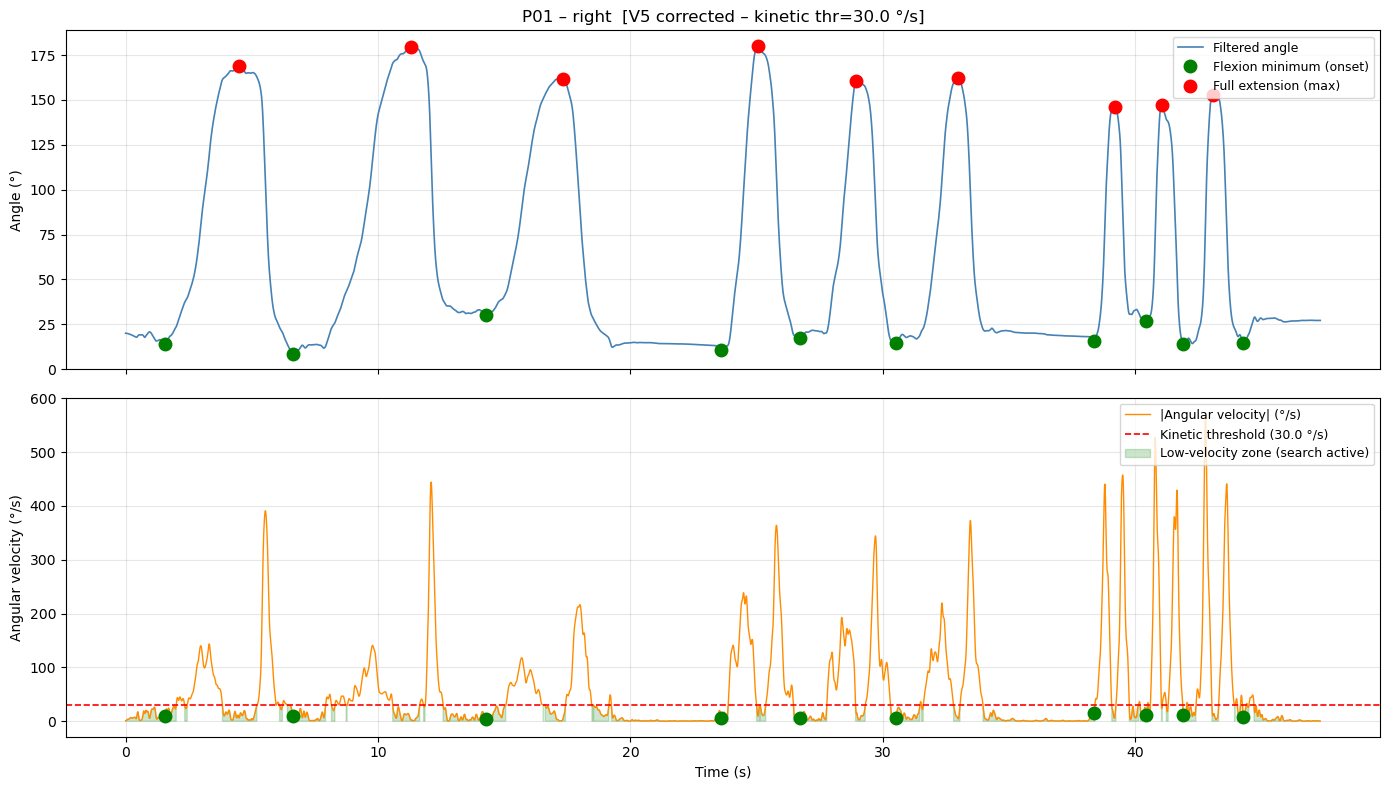


=== DETECTION : P01 | LEFT ===


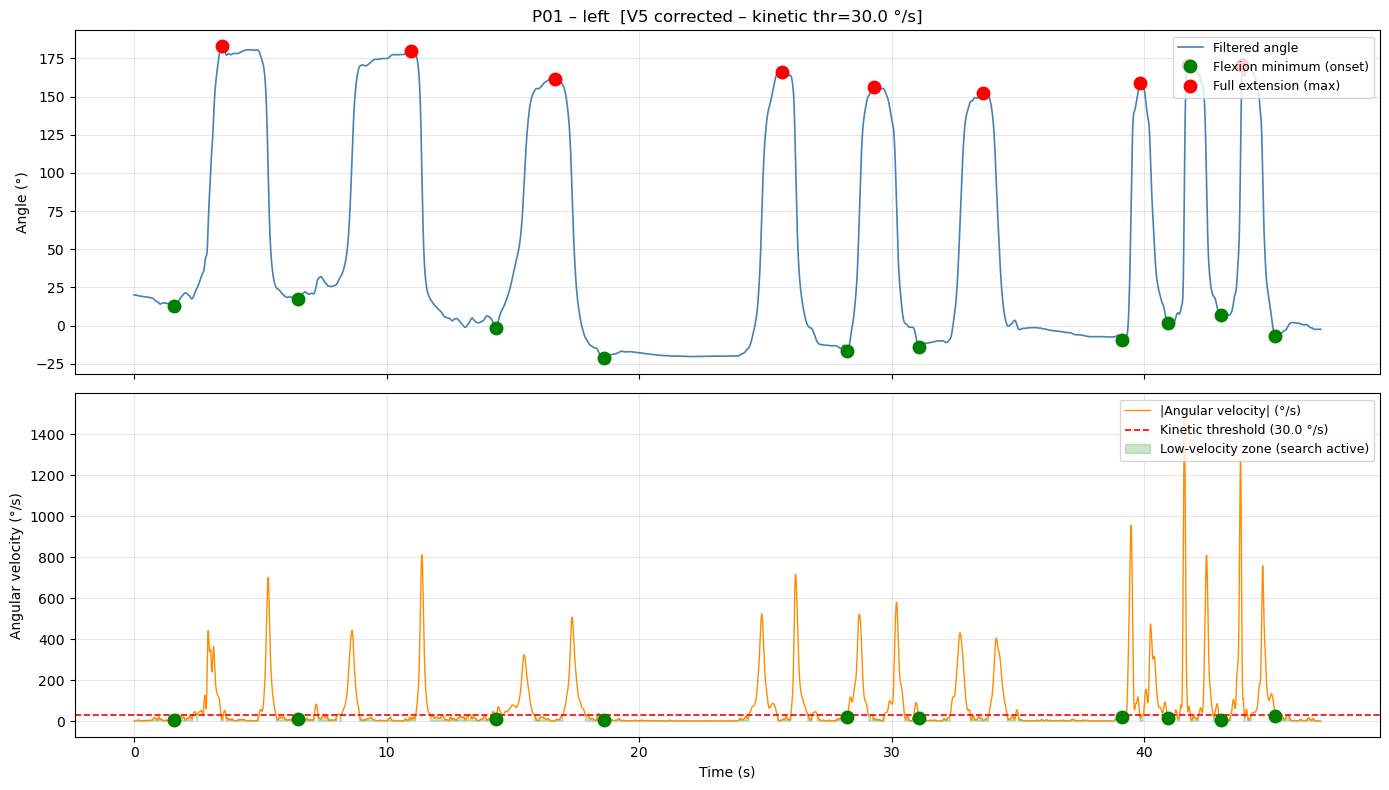


===== EVENTS: P01 | RIGHT =====

TABLE – P01 | right
 event_id speed_category  t_start  t_end  duration  amplitude   velocity
        1          lente   1.5560  4.492    2.9360 154.475865  52.614395
        2          lente   6.6159 11.296    4.6801 170.893314  36.514885
        3          lente  14.2760 17.312    3.0360 131.851319  43.429288
        4        moyenne  23.6039 25.052    1.4481 169.695196 117.184722
        5        moyenne  26.7080 28.936    2.2280 143.397307  64.361448
        6        moyenne  30.5160 33.000    2.4840 147.501872  59.380786
        7         rapide  38.3760 39.184    0.8080 130.482064 161.487703
        8         rapide  40.4440 41.048    0.6040 120.594737 199.660161
        9         rapide  41.9120 43.068    1.1560 138.832630 120.097431


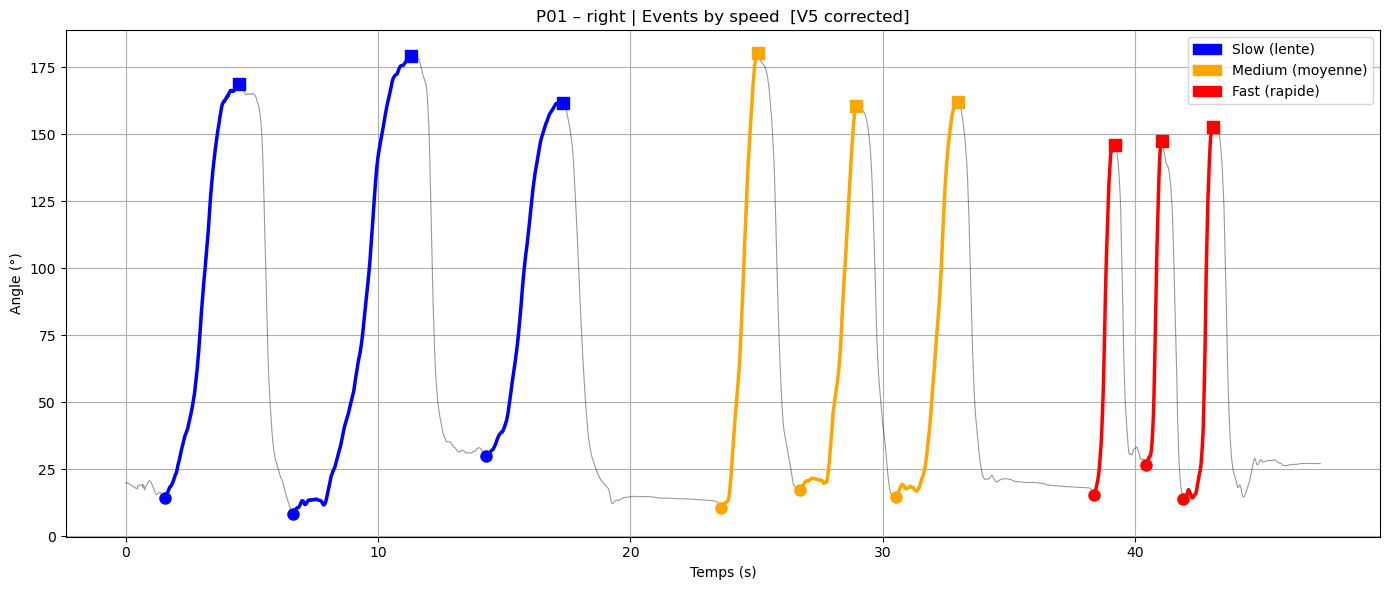


STATISTIQUES :

LENTE (n=3):
  Durée moyenne     : 3.55 s
  Amplitude moyenne : 152.4°
  Vitesse moyenne   : 44.2 °/s

MOYENNE (n=3):
  Durée moyenne     : 2.05 s
  Amplitude moyenne : 153.5°
  Vitesse moyenne   : 80.3 °/s

RAPIDE (n=3):
  Durée moyenne     : 0.86 s
  Amplitude moyenne : 130.0°
  Vitesse moyenne   : 160.4 °/s

===== EVENTS: P01 | LEFT =====

TABLE – P01 | left
 event_id speed_category  t_start   t_end  duration  amplitude   velocity
        1          lente   1.5960  3.4800    1.8840 170.401217  90.446506
        2          lente   6.4760 10.9840    4.5080 162.395935  36.023943
        3          lente  14.3240 16.6640    2.3400 162.773344  69.561258
        4        moyenne  18.6159 25.6440    7.0281 187.593545  26.691929
        5        moyenne  28.2519 29.3040    1.0521 172.604701 164.057315
        6        moyenne  31.0800 33.6280    2.5480 166.497435  65.344362
        7         rapide  39.1400 39.8480    0.7080 168.638220 238.189577
        8         rapide  4

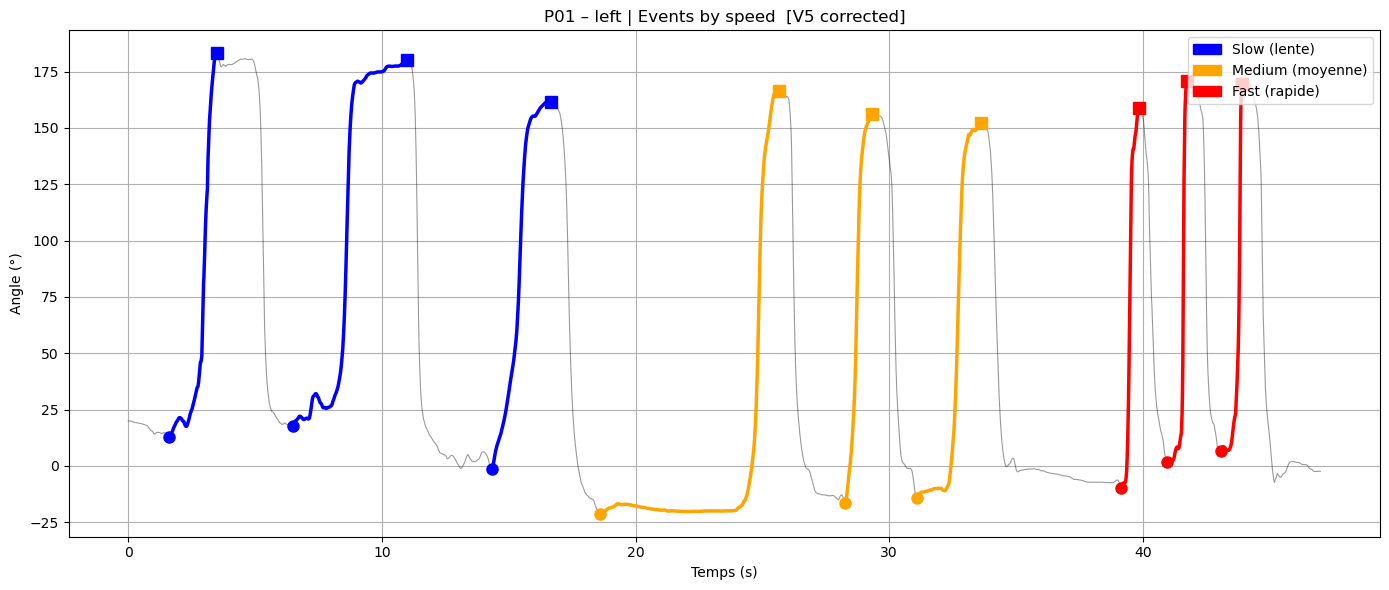


STATISTIQUES :

LENTE (n=3):
  Durée moyenne     : 2.91 s
  Amplitude moyenne : 165.2°
  Vitesse moyenne   : 65.3 °/s

MOYENNE (n=3):
  Durée moyenne     : 3.54 s
  Amplitude moyenne : 175.6°
  Vitesse moyenne   : 85.4 °/s

RAPIDE (n=3):
  Durée moyenne     : 0.78 s
  Amplitude moyenne : 166.9°
  Vitesse moyenne   : 215.1 °/s


In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks

# ==========================================================
# PARAMETERS
# ==========================================================
N_MAX                  = 9
N_MIN                  = 10
MIN_PROM               = 15
MIN_DIST_SEC           = 1.5
FILTER_CUTOFF          = 10

# --- V5 corrected: kinetic zone + angle minimum ---
VELOCITY_ONSET_THRESH  = 30.0   # °/s – samples below this threshold define
                                 # the "rest zone" where the true minimum is sought.
                                 # Increase if onsets are still too early,
                                 # decrease if they are too late.
VELOCITY_SMOOTH_WINDOW = 15     # samples – moving average window for velocity
                                 # smoothing before thresholding (odd integer).

# ==========================================================
# LOW-PASS FILTER
# ==========================================================
def butter_lowpass_filter(signal, cutoff, fs, order=4):
    """Apply a zero-phase Butterworth low-pass filter to the signal."""
    nyq        = 0.5 * fs
    normal_cut = min(cutoff / nyq, 0.99)
    b, a       = butter(order, normal_cut, btype='low')
    return filtfilt(b, a, signal)

# ==========================================================
# SMOOTH VELOCITY COMPUTATION
# ==========================================================
def compute_velocity(signal_f, fs, window=VELOCITY_SMOOTH_WINDOW):
    """
    Compute the smoothed absolute angular velocity of the signal.

    Steps:
      1. Central-difference gradient → raw velocity (°/s).
      2. Uniform moving-average smoothing to reduce IMU noise.

    Parameters
    ----------
    signal_f : np.ndarray – filtered angle signal (°)
    fs       : float      – sampling frequency (Hz)
    window   : int        – smoothing window (samples)

    Returns
    -------
    velocity : np.ndarray – smoothed |dθ/dt| in °/s, same length as signal_f
    """
    raw_vel  = np.gradient(signal_f, 1.0 / fs)
    kernel   = np.ones(window) / window
    velocity = np.convolve(np.abs(raw_vel), kernel, mode='same')
    return velocity

# ==========================================================
# KINETIC ZONE MINIMUM  (core V5 corrected function)
# ==========================================================
def find_minimum_in_kinetic_zone(signal_f, velocity,
                                  search_start, search_end):
    """
    Find the true angle minimum inside the low-velocity zone between
    search_start and search_end.

    Strategy (two-step):
    --------------------
    Step 1 – identify the kinetic rest zone:
        Scan the velocity in [search_start : search_end] and keep only
        the samples where |dθ/dt| < VELOCITY_ONSET_THRESH.
        These samples form the "rest zone" where the limb is not moving
        fast (either pause or end of deceleration).

    Step 2 – find the angle minimum inside that zone:
        Among the rest-zone samples, take the one with the lowest angle
        value (argmin on signal_f).  This is the true flexion minimum,
        anchored in an active low-velocity phase rather than a random
        pause sample.

    Why this is better than the previous V5
    ----------------------------------------
    The previous version returned the *last* sample below the velocity
    threshold (backward scan), which was often in the pause rather than
    at the true angle dip.  By combining the kinetic criterion with
    argmin on the angle, we get a point that is simultaneously:
      • kinetically valid  (velocity is low → limb is near rest)
      • geometrically correct (it is the deepest flexion angle)

    Fallback
    ---------
    If no sample is below the threshold (e.g. very fast movement),
    fall back to plain argmin on the full window.

    Parameters
    ----------
    signal_f     : np.ndarray – filtered angle signal (°)
    velocity     : np.ndarray – smoothed absolute velocity (°/s)
    search_start : int        – start of search window (sample index)
    search_end   : int        – end of search window (sample index)

    Returns
    -------
    int : absolute sample index of the detected onset / minimum
    """
    seg_angle = signal_f[search_start:search_end]
    seg_vel   = velocity[search_start:search_end]

    # Step 1 – mask samples that are in a low-velocity zone
    low_vel_mask = seg_vel < VELOCITY_ONSET_THRESH

    if not np.any(low_vel_mask):
        # Fallback: no sample below threshold → plain argmin
        print(f"    [V5 warn] no sample below {VELOCITY_ONSET_THRESH}°/s "
              f"in [{search_start}:{search_end}] → fallback argmin")
        return search_start + int(np.argmin(seg_angle))

    # Step 2 – among low-velocity samples, find the angle minimum
    masked_angle = seg_angle.copy().astype(float)
    masked_angle[~low_vel_mask] = np.inf   # hide high-velocity samples

    return search_start + int(np.argmin(masked_angle))

# ==========================================================
# EVENT DETECTION  –  V5 CORRECTED : KINETIC ZONE + ARGMIN
# ==========================================================
def detect_clean_events(df_angles):
    """
    Detect extension maxima and flexion minima using a kinetic criterion.

    Full pipeline
    -------------
    1. Butterworth low-pass filter (FILTER_CUTOFF Hz).
    2. Smoothed absolute angular velocity computation.
    3. Extension maxima detection with find_peaks.
    4. For each inter-peak window, locate the angle minimum restricted
       to samples where velocity < VELOCITY_ONSET_THRESH.
       → Pure kinetic criterion: no fixed time window, no anatomical
         threshold, robust to any pause duration.

    Parameters
    ----------
    df_angles : pd.DataFrame – columns 'time' (s) and 'angle' (°).

    Returns
    -------
    minima   : np.ndarray – indices of detected flexion minima
    raw_max  : np.ndarray – indices of full-extension peaks
    signal_f : np.ndarray – filtered angle signal
    velocity : np.ndarray – smoothed velocity (for verification plot)
    """
    time    = df_angles["time"].values
    angle   = df_angles["angle"].values
    fs      = 1.0 / np.mean(np.diff(time))

    # Step 1 – filter
    signal_f = butter_lowpass_filter(angle, FILTER_CUTOFF, fs)

    # Step 2 – velocity
    velocity = compute_velocity(signal_f, fs)

    # Step 3 – maxima
    dist_samples = int(fs * MIN_DIST_SEC)
    raw_max, _   = find_peaks(signal_f,
                               distance=dist_samples,
                               prominence=MIN_PROM)
    if len(raw_max) > N_MAX:
        idx     = np.argsort(signal_f[raw_max])[::-1]
        raw_max = raw_max[idx[:N_MAX]]
    raw_max = np.sort(raw_max)

    # Step 4 – kinetic-zone minima
    minima = []

    if len(raw_max) == 0:
        return np.array([], dtype=int), raw_max, signal_f, velocity

    # --- Minimum before the first maximum ---
    # Search from signal start to first peak
    onset = find_minimum_in_kinetic_zone(
        signal_f, velocity, 0, raw_max[0]
    )
    minima.append(onset)

    # --- Minimum between consecutive maxima ---
    for i in range(len(raw_max) - 1):
        left  = raw_max[i]
        right = raw_max[i + 1]
        if right - left > 5:
            onset = find_minimum_in_kinetic_zone(
                signal_f, velocity, left, right
            )
            minima.append(onset)

    # --- Minimum after the last maximum ---
    last_peak = raw_max[-1]
    if len(signal_f) - last_peak > 5:
        onset = find_minimum_in_kinetic_zone(
            signal_f, velocity, last_peak, len(signal_f)
        )
        minima.append(onset)

    minima = np.array(minima, dtype=int)
    minima = np.unique(minima)

    if len(minima) > N_MIN:
        minima = minima[:N_MIN]
    elif 0 < len(minima) < N_MIN:
        minima = np.pad(minima, (0, N_MIN - len(minima)), mode='edge')

    return minima, raw_max, signal_f, velocity

# ==========================================================
# PLOT + STORE  (angle + velocity on same figure)
# ==========================================================
def plot_and_store(df_angles, minima, maxima, signal_f, velocity,
                   patient_name, side, events_results):
    """
    Store results and display a two-panel verification figure:
      Top    : filtered angle with onsets (green) and peaks (red)
      Bottom : smoothed velocity with threshold line and onset markers
    Both panels share the same x-axis for easy cross-reading.
    """
    events_results.setdefault(patient_name, {})
    events_results[patient_name][side] = {
        "angles"          : df_angles,
        "signal_filtered" : signal_f,
        "peaks_flexion"   : minima,
        "peaks_extension" : maxima,
        "velocity"        : velocity
    }

    time = df_angles["time"].values

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

    # --- Top: angle ---
    ax1.plot(time, signal_f, color='steelblue', linewidth=1.2,
             label='Filtered angle')
    if len(minima) > 0:
        ax1.plot(time[minima], signal_f[minima], 'go',
                 ms=9, zorder=3, label='Flexion minimum (onset)')
    if len(maxima) > 0:
        ax1.plot(time[maxima], signal_f[maxima], 'ro',
                 ms=9, zorder=3, label='Full extension (max)')
    ax1.set_ylabel('Angle (°)')
    ax1.set_title(f'{patient_name} – {side}  '
                  f'[V5 corrected – kinetic thr={VELOCITY_ONSET_THRESH} °/s]')
    ax1.legend(loc='upper right', fontsize=9)
    ax1.grid(True, alpha=0.3)

    # --- Bottom: velocity ---
    ax2.plot(time, velocity, color='darkorange', linewidth=1.0,
             label='|Angular velocity| (°/s)')
    ax2.axhline(y=VELOCITY_ONSET_THRESH, color='red',
                linestyle='--', linewidth=1.2,
                label=f'Kinetic threshold ({VELOCITY_ONSET_THRESH} °/s)')
    # Shade the low-velocity zones so you can see where the search is active
    ax2.fill_between(time, 0, velocity,
                     where=(velocity < VELOCITY_ONSET_THRESH),
                     alpha=0.2, color='green',
                     label='Low-velocity zone (search active)')
    if len(minima) > 0:
        ax2.plot(time[minima], velocity[minima], 'go', ms=9, zorder=3)
    ax2.set_ylabel('Angular velocity (°/s)')
    ax2.set_xlabel('Time (s)')
    ax2.legend(loc='upper right', fontsize=9)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# ==========================================================
# MULTI-PATIENT DETECTION LOOP
# ==========================================================
events_results = {}

for patient_name, pdata in results.items():
    for side, data in pdata.items():

        print(f"\n=== DETECTION : {patient_name} | {side.upper()} ===")

        df       = data["wrist"]
        baseline = data["baseline"]["wrist"]

        df_angles = quaternion_to_angle_y_calibrated(df, baseline, baseline_deg=20)

        minima, maxima, signal_f, velocity = detect_clean_events(df_angles)

        plot_and_store(df_angles, minima, maxima, signal_f, velocity,
                       patient_name, side, events_results)

# ==========================================================
# EVENTS ANALYSIS
# ==========================================================
all_events_summary = {}

for patient_name in events_results:
    all_events_summary[patient_name] = {}

    for side in events_results[patient_name]:

        print(f"\n===== EVENTS: {patient_name} | {side.upper()} =====")

        data            = events_results[patient_name][side]
        df_angles       = data["angles"]
        peaks_flexion   = data["peaks_flexion"]
        peaks_extension = data["peaks_extension"]
        signal          = df_angles["angle"].values
        time            = df_angles["time"].values

        events = []

        if len(peaks_flexion) < 2 or len(peaks_extension) == 0:
            print("⚠️  Not enough peaks to build events.")
            continue

        n_events = min(len(peaks_extension), len(peaks_flexion) - 1)

        for i in range(n_events):
            min_idx     = peaks_flexion[i]
            max_idx     = peaks_extension[i]
            t_start     = time[min_idx]
            t_end       = time[max_idx]
            duration    = t_end - t_start
            angle_start = signal[min_idx]
            angle_end   = signal[max_idx]
            amplitude   = angle_end - angle_start
            velocity_ev = amplitude / duration if duration > 0 else 0

            events.append({
                'event_id'    : i + 1,
                'min_idx'     : min_idx,
                'max_idx'     : max_idx,
                't_start'     : t_start,
                't_end'       : t_end,
                'duration'    : duration,
                'angle_start' : angle_start,
                'angle_end'   : angle_end,
                'amplitude'   : amplitude,
                'velocity'    : velocity_ev
            })

        speed_labels = ['lente'] * 3 + ['moyenne'] * 3 + ['rapide'] * 3
        for i, event in enumerate(events):
            event['speed_category'] = (speed_labels[i]
                                       if i < len(speed_labels) else 'extra')

        df_events = pd.DataFrame(events)
        all_events_summary[patient_name][side] = df_events

        # ------ TABLE ------
        print("\n" + "=" * 60)
        print(f"TABLE – {patient_name} | {side}")
        print("=" * 60)
        if not df_events.empty:
            print(df_events[['event_id', 'speed_category',
                              't_start', 't_end',
                              'duration', 'amplitude',
                              'velocity']].to_string(index=False))
        else:
            print("No events detected.")

        # ------ PLOT EVENTS BY SPEED ------
        colors_speed = {
            'lente'  : 'blue',
            'moyenne': 'orange',
            'rapide' : 'red',
            'extra'  : 'gray'
        }

        plt.figure(figsize=(14, 6))
        plt.plot(time, signal, 'k-', linewidth=0.8, alpha=0.4)

        for event in events:
            color     = colors_speed[event['speed_category']]
            idx_range = np.arange(event['min_idx'], event['max_idx'] + 1)
            plt.plot(time[idx_range], signal[idx_range],
                     color=color, linewidth=2.5)
            plt.plot(time[event['min_idx']], signal[event['min_idx']],
                     'o', color=color, ms=8)
            plt.plot(time[event['max_idx']], signal[event['max_idx']],
                     's', color=color, ms=8)

        from matplotlib.patches import Patch
        legend_handles = [
            Patch(color='blue',   label='Slow (lente)'),
            Patch(color='orange', label='Medium (moyenne)'),
            Patch(color='red',    label='Fast (rapide)'),
        ]
        plt.legend(handles=legend_handles, loc='upper right')
        plt.title(f"{patient_name} – {side} | Events by speed  [V5 corrected]")
        plt.xlabel("Temps (s)")
        plt.ylabel("Angle (°)")
        plt.grid(True)
        plt.tight_layout()
        plt.show()

        # ------ STATS ------
        print("\nSTATISTIQUES :")
        for cat in ['lente', 'moyenne', 'rapide']:
            subset = df_events[df_events['speed_category'] == cat]
            if len(subset) == 0:
                continue
            print(f"\n{cat.upper()} (n={len(subset)}):")
            print(f"  Durée moyenne     : {subset['duration'].mean():.2f} s")
            print(f"  Amplitude moyenne : {subset['amplitude'].mean():.1f}°")
            print(f"  Vitesse moyenne   : {subset['velocity'].mean():.1f} °/s")


=== DETECTION : P01 | RIGHT ===
    Peak 1 at t=4.49s → onset at t=4.49s (angle=168.7°, vel=8.3°/s)
    Peak 2 at t=11.30s → onset at t=11.29s (angle=179.3°, vel=3.8°/s)
    Peak 3 at t=17.31s → onset at t=17.31s (angle=161.8°, vel=2.9°/s)
    Peak 4 at t=25.05s → onset at t=25.05s (angle=180.2°, vel=13.6°/s)
    Peak 5 at t=28.94s → onset at t=27.77s (angle=20.2°, vel=19.9°/s)
    Peak 6 at t=33.00s → onset at t=33.00s (angle=162.0°, vel=6.6°/s)
    Peak 7 at t=39.18s → onset at t=39.18s (angle=145.8°, vel=8.3°/s)
    Peak 8 at t=41.05s → onset at t=40.58s (angle=29.7°, vel=18.8°/s)
    Peak 9 at t=43.07s → onset at t=43.06s (angle=152.7°, vel=18.0°/s)


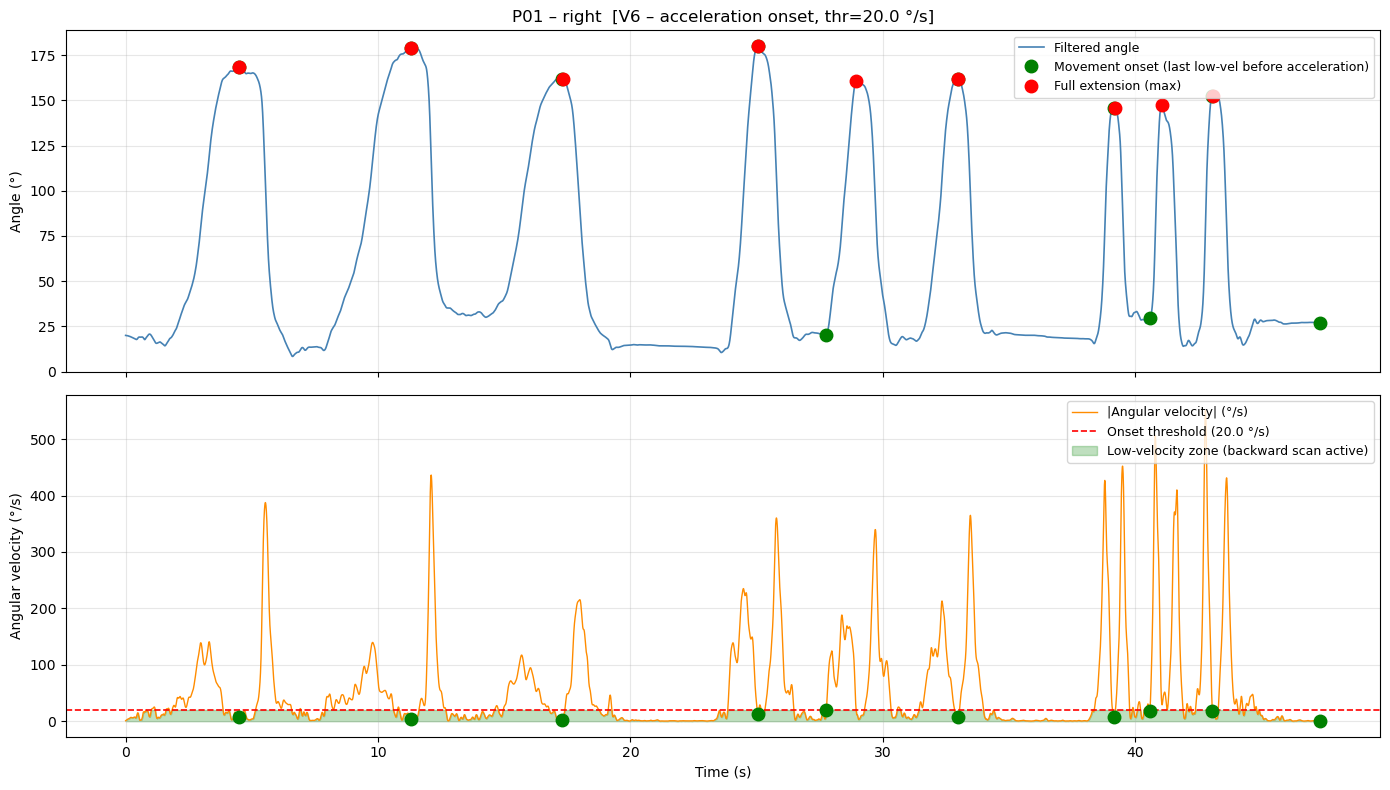


=== DETECTION : P01 | LEFT ===
    Peak 1 at t=3.48s → onset at t=3.48s (angle=183.1°, vel=14.6°/s)
    Peak 2 at t=10.98s → onset at t=10.98s (angle=180.1°, vel=10.7°/s)
    Peak 3 at t=16.66s → onset at t=16.66s (angle=161.4°, vel=1.7°/s)
    Peak 4 at t=25.64s → onset at t=25.64s (angle=166.4°, vel=4.6°/s)
    Peak 5 at t=29.30s → onset at t=29.30s (angle=156.0°, vel=11.0°/s)
    Peak 6 at t=33.63s → onset at t=33.62s (angle=152.4°, vel=4.9°/s)
    Peak 7 at t=39.85s → onset at t=39.29s (angle=-7.5°, vel=19.0°/s)
    Peak 8 at t=41.74s → onset at t=41.39s (angle=7.7°, vel=19.1°/s)
    Peak 9 at t=43.89s → onset at t=43.41s (angle=7.4°, vel=18.6°/s)


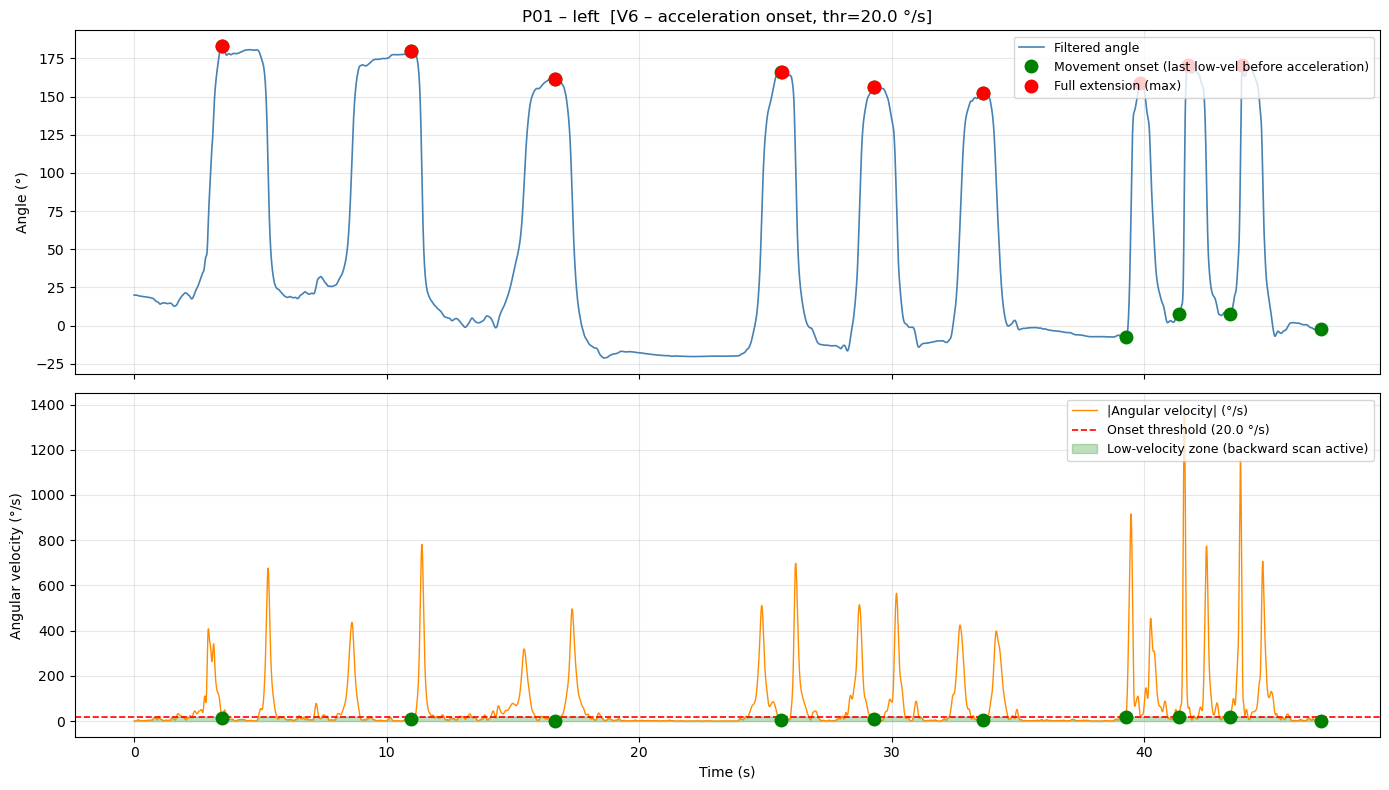


===== EVENTS: P01 | RIGHT =====

TABLE – P01 | right
 event_id speed_category  t_start  t_end  duration  amplitude   velocity
        1          lente    4.488  4.492     0.004  -0.010161  -2.540323
        2          lente   11.292 11.296     0.004   0.010387   2.596714
        3          lente   17.308 17.312     0.004   0.003961   0.990365
        4        moyenne   25.048 25.052     0.004   0.019625   4.906206
        5        moyenne   27.768 28.936     1.168 140.461720 120.258322
        6        moyenne   32.996 33.000     0.004   0.000009   0.002218
        7         rapide   39.180 39.184     0.004  -0.008447  -2.111727
        8         rapide   40.584 41.048     0.464 117.725105 253.717899
        9         rapide   43.064 43.068     0.004   0.035681   8.920194


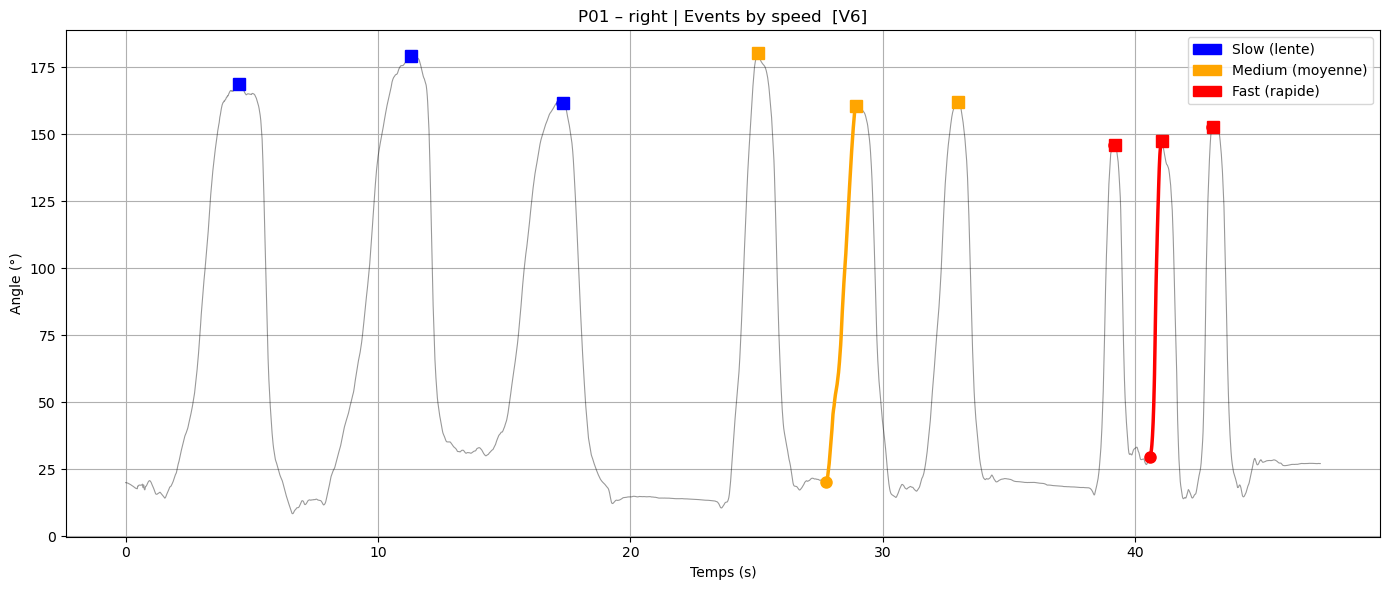


STATISTIQUES :

LENTE (n=3):
  Durée moyenne     : 0.00 s
  Amplitude moyenne : 0.0°
  Vitesse moyenne   : 0.3 °/s

MOYENNE (n=3):
  Durée moyenne     : 0.39 s
  Amplitude moyenne : 46.8°
  Vitesse moyenne   : 41.7 °/s

RAPIDE (n=3):
  Durée moyenne     : 0.16 s
  Amplitude moyenne : 39.3°
  Vitesse moyenne   : 86.8 °/s

===== EVENTS: P01 | LEFT =====

TABLE – P01 | left
 event_id speed_category  t_start   t_end  duration  amplitude   velocity
        1          lente    3.476  3.4800    0.0040  -0.033733  -8.433238
        2          lente   10.980 10.9840    0.0040   0.009664   2.415885
        3          lente   16.660 16.6640    0.0040  -0.003326  -0.831434
        4        moyenne   25.640 25.6440    0.0040  -0.002150  -0.537433
        5        moyenne   29.300 29.3040    0.0040   0.001667   0.416868
        6        moyenne   33.624 33.6280    0.0040  -0.004737  -1.184232
        7         rapide   39.288 39.8480    0.5600 166.313845 296.989009
        8         rapide   41.388

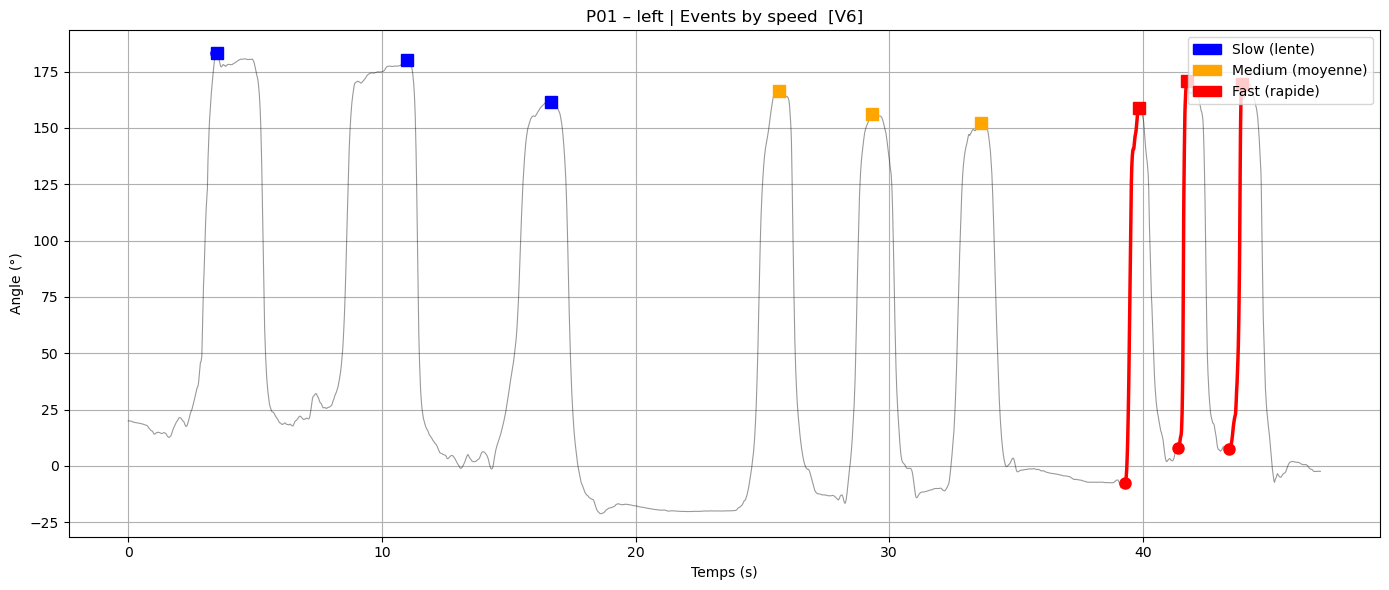


STATISTIQUES :

LENTE (n=3):
  Durée moyenne     : 0.00 s
  Amplitude moyenne : -0.0°
  Vitesse moyenne   : -2.3 °/s

MOYENNE (n=3):
  Durée moyenne     : 0.00 s
  Amplitude moyenne : -0.0°
  Vitesse moyenne   : -0.4 °/s

RAPIDE (n=3):
  Durée moyenne     : 0.46 s
  Amplitude moyenne : 163.9°
  Vitesse moyenne   : 366.3 °/s


In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.signal import butter, filtfilt, find_peaks

# ==========================================================
# PARAMETERS
# ==========================================================
N_MAX                  = 9
N_MIN                  = 10
MIN_PROM               = 15
MIN_DIST_SEC           = 1.5
FILTER_CUTOFF          = 10

# --- V6: acceleration onset parameters ---
VELOCITY_ONSET_THRESH  = 20.0   # °/s – velocity must cross this threshold
                                 # going upward to mark the start of movement.
                                 # The onset = last sample BEFORE this crossing,
                                 # i.e. the last low-velocity sample just before
                                 # the limb starts accelerating toward the peak.
VELOCITY_SMOOTH_WINDOW = 21     # samples – smoothing window for velocity
                                 # (larger = smoother, less sensitive to noise spikes)

# ==========================================================
# LOW-PASS FILTER
# ==========================================================
def butter_lowpass_filter(signal, cutoff, fs, order=4):
    """Apply a zero-phase Butterworth low-pass filter to the signal."""
    nyq        = 0.5 * fs
    normal_cut = min(cutoff / nyq, 0.99)
    b, a       = butter(order, normal_cut, btype='low')
    return filtfilt(b, a, signal)

# ==========================================================
# SMOOTH VELOCITY
# ==========================================================
def compute_velocity(signal_f, fs, window=VELOCITY_SMOOTH_WINDOW):
    """
    Compute the smoothed absolute angular velocity.

    Parameters
    ----------
    signal_f : np.ndarray – filtered angle signal (°)
    fs       : float      – sampling frequency (Hz)
    window   : int        – moving-average window (samples)

    Returns
    -------
    velocity : np.ndarray – smoothed |dθ/dt| in °/s
    """
    raw_vel  = np.gradient(signal_f, 1.0 / fs)
    kernel   = np.ones(window) / window
    velocity = np.convolve(np.abs(raw_vel), kernel, mode='same')
    return velocity

# ==========================================================
# FIND LAST CROSSING BELOW THRESHOLD BEFORE A PEAK  (core V6)
# ==========================================================
def find_acceleration_onset(velocity, search_start, peak_idx):
    """
    Find the movement onset by detecting the last upward crossing of
    VELOCITY_ONSET_THRESH in the window [search_start : peak_idx].

    Rationale
    ---------
    Just before each extension peak, the angular velocity rises steeply
    (acceleration phase).  This function locates the LAST moment where
    velocity was still below the threshold before this rise — i.e., the
    sample just before the limb started accelerating toward the peak.

    This approach is fundamentally different from previous versions:
    instead of searching for a low-velocity zone anywhere in the window
    (which could land in the preceding ~5 s pause), it anchors the onset
    to the acceleration that is CAUSALLY LINKED to the current peak.

    Algorithm (backward scan from the peak)
    ----------------------------------------
    1. Take the velocity segment from search_start to peak_idx.
    2. Scan BACKWARDS from peak_idx.
    3. Stop at the first sample where velocity drops below threshold.
       → That sample is the last "rest" sample before the acceleration
         that produced the current peak.
    4. The angle minimum in a short confirmation window around that
       sample is returned as the true onset index.

    Parameters
    ----------
    velocity     : np.ndarray – smoothed absolute velocity (°/s)
    search_start : int        – start of search window (sample index)
    peak_idx     : int        – index of the extension maximum

    Returns
    -------
    int : absolute sample index of the detected onset
    """
    seg_vel = velocity[search_start:peak_idx]
    n       = len(seg_vel)

    if n < 3:
        return search_start

    # Backward scan: find the last sample below the threshold
    # before the rising velocity that leads to the peak.
    onset_local = 0   # fallback = start of window
    for j in range(n - 1, -1, -1):
        if seg_vel[j] < VELOCITY_ONSET_THRESH:
            onset_local = j
            break

    return search_start + onset_local


# ==========================================================
# EVENT DETECTION  –  V6 : ACCELERATION ONSET BEFORE EACH PEAK
# ==========================================================
def detect_clean_events(df_angles):
    """
    Detect extension maxima and movement-onset minima.

    Strategy (V6) — key insight
    ----------------------------
    Every extension peak is preceded by an acceleration phase where
    velocity rises sharply above the threshold.  The onset of that
    acceleration (= last low-velocity sample before the rise) is the
    true start of the movement, regardless of what happened before
    (pause, noise, slow drift).

    By searching BACKWARDS from each peak and stopping at the first
    velocity drop below threshold, we are guaranteed to find the onset
    of the acceleration that generated THAT specific peak — not a
    random low-velocity sample in the preceding pause.

    This breaks the ambiguity that plagued V2–V5: even if the pause
    also has low velocity, the backward scan will first encounter the
    deceleration at the END of the current movement, not the pause.

    Steps
    -----
    1. Butterworth low-pass filter.
    2. Smoothed absolute velocity computation.
    3. Extension maxima detection (find_peaks).
    4. For each maximum, backward scan to find the last sample below
       VELOCITY_ONSET_THRESH → movement onset.
    5. The reported minimum is the angle value at that onset sample.

    Parameters
    ----------
    df_angles : pd.DataFrame – columns 'time' (s) and 'angle' (°).

    Returns
    -------
    minima   : np.ndarray – onset indices
    raw_max  : np.ndarray – extension peak indices
    signal_f : np.ndarray – filtered angle signal
    velocity : np.ndarray – smoothed velocity
    """
    time    = df_angles["time"].values
    angle   = df_angles["angle"].values
    fs      = 1.0 / np.mean(np.diff(time))

    # Step 1 – filter
    signal_f = butter_lowpass_filter(angle, FILTER_CUTOFF, fs)

    # Step 2 – velocity
    velocity = compute_velocity(signal_f, fs)

    # Step 3 – maxima
    dist_samples = int(fs * MIN_DIST_SEC)
    raw_max, _   = find_peaks(signal_f,
                               distance=dist_samples,
                               prominence=MIN_PROM)
    if len(raw_max) > N_MAX:
        idx     = np.argsort(signal_f[raw_max])[::-1]
        raw_max = raw_max[idx[:N_MAX]]
    raw_max = np.sort(raw_max)

    if len(raw_max) == 0:
        return np.array([], dtype=int), raw_max, signal_f, velocity

    # Step 4 – for each peak, find onset by backward scan
    minima = []

    for i, peak_idx in enumerate(raw_max):

        # Define the search start:
        # use the previous peak as the left boundary so the scan
        # cannot reach further back than the previous movement.
        if i == 0:
            search_start = 0
        else:
            search_start = raw_max[i - 1]   # start from previous peak

        onset = find_acceleration_onset(velocity, search_start, peak_idx)
        minima.append(onset)
        print(f"    Peak {i+1} at t={time[peak_idx]:.2f}s → "
              f"onset at t={time[onset]:.2f}s "
              f"(angle={signal_f[onset]:.1f}°, "
              f"vel={velocity[onset]:.1f}°/s)")

    # Onset after the last peak (end of last flexion)
    last_peak = raw_max[-1]
    if len(signal_f) - last_peak > 5:
        seg_vel     = velocity[last_peak:]
        onset_local = 0
        for j in range(len(seg_vel) - 1, -1, -1):
            if seg_vel[j] < VELOCITY_ONSET_THRESH:
                onset_local = j
                break
        minima.append(last_peak + onset_local)

    minima = np.array(minima, dtype=int)
    minima = np.unique(minima)

    if len(minima) > N_MIN:
        minima = minima[:N_MIN]
    elif 0 < len(minima) < N_MIN:
        minima = np.pad(minima, (0, N_MIN - len(minima)), mode='edge')

    return minima, raw_max, signal_f, velocity

# ==========================================================
# PLOT + STORE
# ==========================================================
def plot_and_store(df_angles, minima, maxima, signal_f, velocity,
                   patient_name, side, events_results):
    """
    Store results and display a two-panel verification figure.

    Top panel   : filtered angle with onset markers and extension peaks.
    Bottom panel: smoothed velocity with threshold line.
                  Green shading = samples below threshold where the
                  backward scan is active.
                  The onset marker on the velocity panel shows the
                  exact velocity value at detection → should be near 0.
    """
    events_results.setdefault(patient_name, {})
    events_results[patient_name][side] = {
        "angles"          : df_angles,
        "signal_filtered" : signal_f,
        "peaks_flexion"   : minima,
        "peaks_extension" : maxima,
        "velocity"        : velocity
    }

    time = df_angles["time"].values

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

    # --- Angle panel ---
    ax1.plot(time, signal_f, color='steelblue', linewidth=1.2,
             label='Filtered angle')
    if len(minima) > 0:
        ax1.plot(time[minima], signal_f[minima], 'go',
                 ms=9, zorder=3,
                 label='Movement onset (last low-vel before acceleration)')
    if len(maxima) > 0:
        ax1.plot(time[maxima], signal_f[maxima], 'ro',
                 ms=9, zorder=3, label='Full extension (max)')
    ax1.set_ylabel('Angle (°)')
    ax1.set_title(f'{patient_name} – {side}  '
                  f'[V6 – acceleration onset, thr={VELOCITY_ONSET_THRESH} °/s]')
    ax1.legend(loc='upper right', fontsize=9)
    ax1.grid(True, alpha=0.3)

    # --- Velocity panel ---
    ax2.plot(time, velocity, color='darkorange', linewidth=1.0,
             label='|Angular velocity| (°/s)')
    ax2.axhline(y=VELOCITY_ONSET_THRESH, color='red',
                linestyle='--', linewidth=1.2,
                label=f'Onset threshold ({VELOCITY_ONSET_THRESH} °/s)')
    ax2.fill_between(time, 0, np.minimum(velocity, VELOCITY_ONSET_THRESH),
                     alpha=0.25, color='green',
                     label='Low-velocity zone (backward scan active)')
    if len(minima) > 0:
        ax2.plot(time[minima], velocity[minima], 'go', ms=9, zorder=3)
    ax2.set_ylabel('Angular velocity (°/s)')
    ax2.set_xlabel('Time (s)')
    ax2.legend(loc='upper right', fontsize=9)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# ==========================================================
# MULTI-PATIENT DETECTION LOOP
# ==========================================================
events_results = {}

for patient_name, pdata in results.items():
    for side, data in pdata.items():

        print(f"\n=== DETECTION : {patient_name} | {side.upper()} ===")

        df       = data["wrist"]
        baseline = data["baseline"]["wrist"]

        df_angles = quaternion_to_angle_y_calibrated(df, baseline, baseline_deg=20)

        minima, maxima, signal_f, velocity = detect_clean_events(df_angles)

        plot_and_store(df_angles, minima, maxima, signal_f, velocity,
                       patient_name, side, events_results)

# ==========================================================
# EVENTS ANALYSIS
# ==========================================================
all_events_summary = {}

for patient_name in events_results:
    all_events_summary[patient_name] = {}

    for side in events_results[patient_name]:

        print(f"\n===== EVENTS: {patient_name} | {side.upper()} =====")

        data            = events_results[patient_name][side]
        df_angles       = data["angles"]
        peaks_flexion   = data["peaks_flexion"]
        peaks_extension = data["peaks_extension"]
        signal          = df_angles["angle"].values
        time            = df_angles["time"].values

        events = []

        if len(peaks_flexion) < 2 or len(peaks_extension) == 0:
            print("⚠️  Not enough peaks to build events.")
            continue

        n_events = min(len(peaks_extension), len(peaks_flexion) - 1)

        for i in range(n_events):
            min_idx     = peaks_flexion[i]
            max_idx     = peaks_extension[i]
            t_start     = time[min_idx]
            t_end       = time[max_idx]
            duration    = t_end - t_start
            angle_start = signal[min_idx]
            angle_end   = signal[max_idx]
            amplitude   = angle_end - angle_start
            velocity_ev = amplitude / duration if duration > 0 else 0

            events.append({
                'event_id'    : i + 1,
                'min_idx'     : min_idx,
                'max_idx'     : max_idx,
                't_start'     : t_start,
                't_end'       : t_end,
                'duration'    : duration,
                'angle_start' : angle_start,
                'angle_end'   : angle_end,
                'amplitude'   : amplitude,
                'velocity'    : velocity_ev
            })

        speed_labels = ['lente'] * 3 + ['moyenne'] * 3 + ['rapide'] * 3
        for i, event in enumerate(events):
            event['speed_category'] = (speed_labels[i]
                                       if i < len(speed_labels) else 'extra')

        df_events = pd.DataFrame(events)
        all_events_summary[patient_name][side] = df_events

        # ------ TABLE ------
        print("\n" + "=" * 60)
        print(f"TABLE – {patient_name} | {side}")
        print("=" * 60)
        if not df_events.empty:
            print(df_events[['event_id', 'speed_category',
                              't_start', 't_end',
                              'duration', 'amplitude',
                              'velocity']].to_string(index=False))
        else:
            print("No events detected.")

        # ------ PLOT EVENTS BY SPEED ------
        colors_speed = {
            'lente'  : 'blue',
            'moyenne': 'orange',
            'rapide' : 'red',
            'extra'  : 'gray'
        }

        plt.figure(figsize=(14, 6))
        plt.plot(time, signal, 'k-', linewidth=0.8, alpha=0.4)

        for event in events:
            color     = colors_speed[event['speed_category']]
            idx_range = np.arange(event['min_idx'], event['max_idx'] + 1)
            plt.plot(time[idx_range], signal[idx_range],
                     color=color, linewidth=2.5)
            plt.plot(time[event['min_idx']], signal[event['min_idx']],
                     'o', color=color, ms=8)
            plt.plot(time[event['max_idx']], signal[event['max_idx']],
                     's', color=color, ms=8)

        legend_handles = [
            Patch(color='blue',   label='Slow (lente)'),
            Patch(color='orange', label='Medium (moyenne)'),
            Patch(color='red',    label='Fast (rapide)'),
        ]
        plt.legend(handles=legend_handles, loc='upper right')
        plt.title(f"{patient_name} – {side} | Events by speed  [V6]")
        plt.xlabel("Temps (s)")
        plt.ylabel("Angle (°)")
        plt.grid(True)
        plt.tight_layout()
        plt.show()

        # ------ STATS ------
        print("\nSTATISTIQUES :")
        for cat in ['lente', 'moyenne', 'rapide']:
            subset = df_events[df_events['speed_category'] == cat]
            if len(subset) == 0:
                continue
            print(f"\n{cat.upper()} (n={len(subset)}):")
            print(f"  Durée moyenne     : {subset['duration'].mean():.2f} s")
            print(f"  Amplitude moyenne : {subset['amplitude'].mean():.1f}°")
            print(f"  Vitesse moyenne   : {subset['velocity'].mean():.1f} °/s")


=== DETECTION : P01 | RIGHT ===


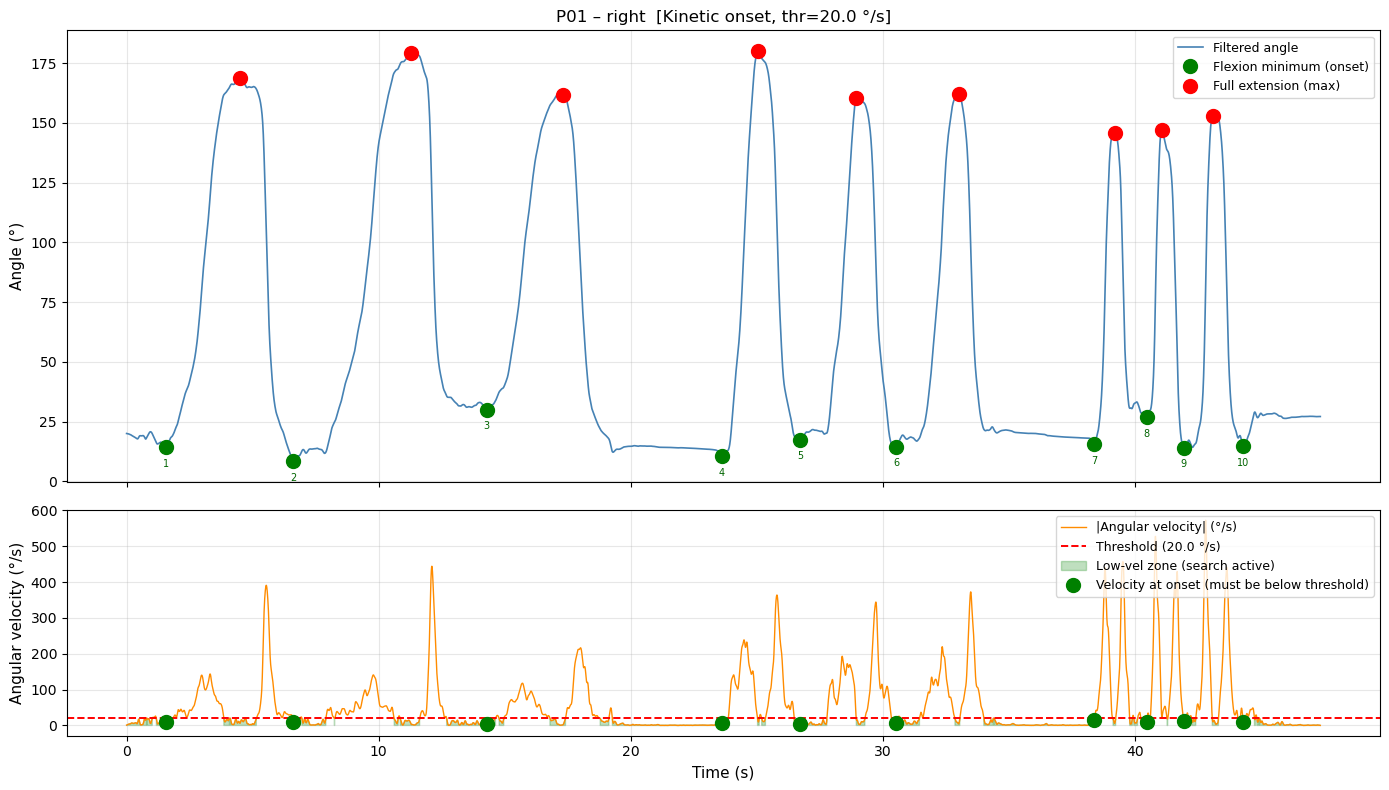


=== DETECTION : P01 | LEFT ===


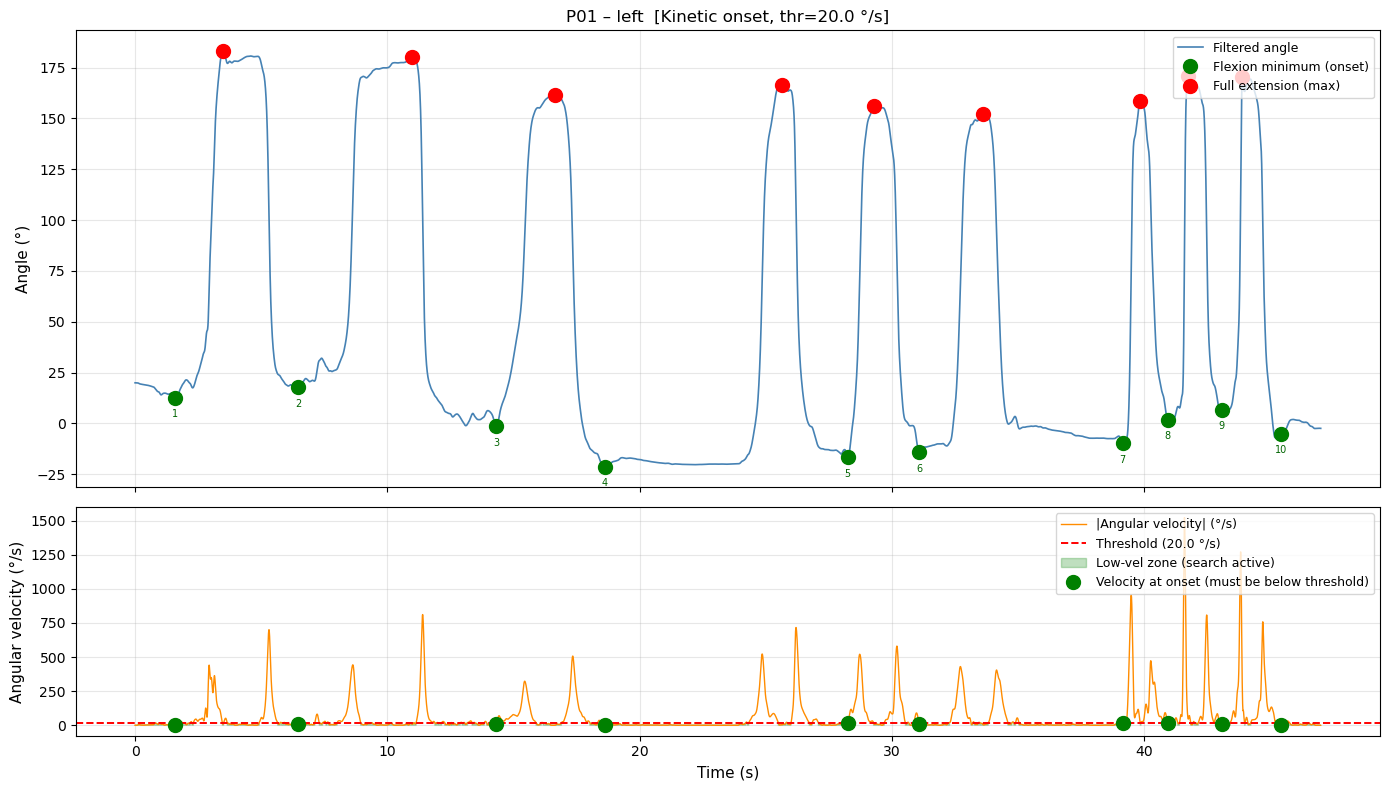


===== EVENTS: P01 | RIGHT =====

TABLE – P01 | right
 event_id speed_category  t_start  t_end  duration  amplitude   velocity
        1          lente   1.5560  4.492    2.9360 154.475865  52.614395
        2          lente   6.6159 11.296    4.6801 170.893314  36.514885
        3          lente  14.2760 17.312    3.0360 131.851319  43.429288
        4        moyenne  23.6039 25.052    1.4481 169.695196 117.184722
        5        moyenne  26.7080 28.936    2.2280 143.397307  64.361448
        6        moyenne  30.5160 33.000    2.4840 147.501872  59.380786
        7         rapide  38.3760 39.184    0.8080 130.482064 161.487703
        8         rapide  40.4440 41.048    0.6040 120.594737 199.660161
        9         rapide  41.9120 43.068    1.1560 138.832630 120.097431


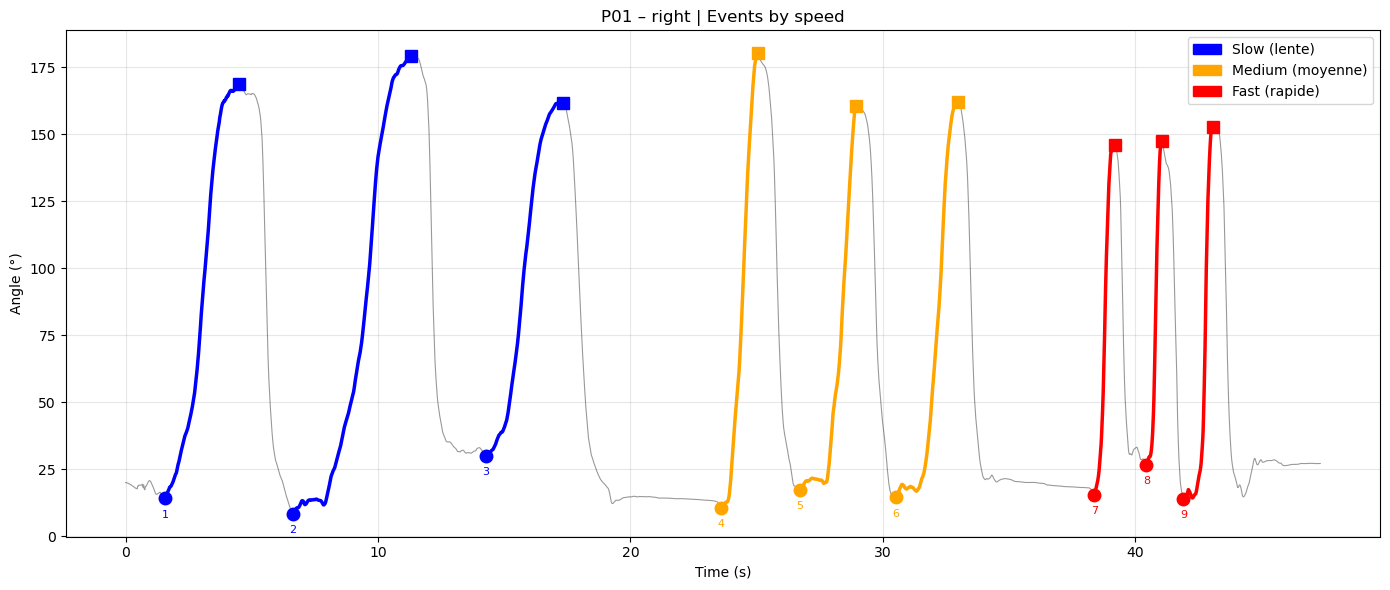


STATISTIQUES :

LENTE (n=3):
  Durée moyenne     : 3.55 s
  Amplitude moyenne : 152.4°
  Vitesse moyenne   : 44.2 °/s

MOYENNE (n=3):
  Durée moyenne     : 2.05 s
  Amplitude moyenne : 153.5°
  Vitesse moyenne   : 80.3 °/s

RAPIDE (n=3):
  Durée moyenne     : 0.86 s
  Amplitude moyenne : 130.0°
  Vitesse moyenne   : 160.4 °/s

===== EVENTS: P01 | LEFT =====

TABLE – P01 | left
 event_id speed_category  t_start   t_end  duration  amplitude   velocity
        1          lente   1.5960  3.4800    1.8840 170.401217  90.446506
        2          lente   6.4760 10.9840    4.5080 162.395935  36.023943
        3          lente  14.3240 16.6640    2.3400 162.773344  69.561258
        4        moyenne  18.6159 25.6440    7.0281 187.593545  26.691929
        5        moyenne  28.2519 29.3040    1.0521 172.604701 164.057315
        6        moyenne  31.0800 33.6280    2.5480 166.497435  65.344362
        7         rapide  39.1400 39.8480    0.7080 168.638220 238.189577
        8         rapide  4

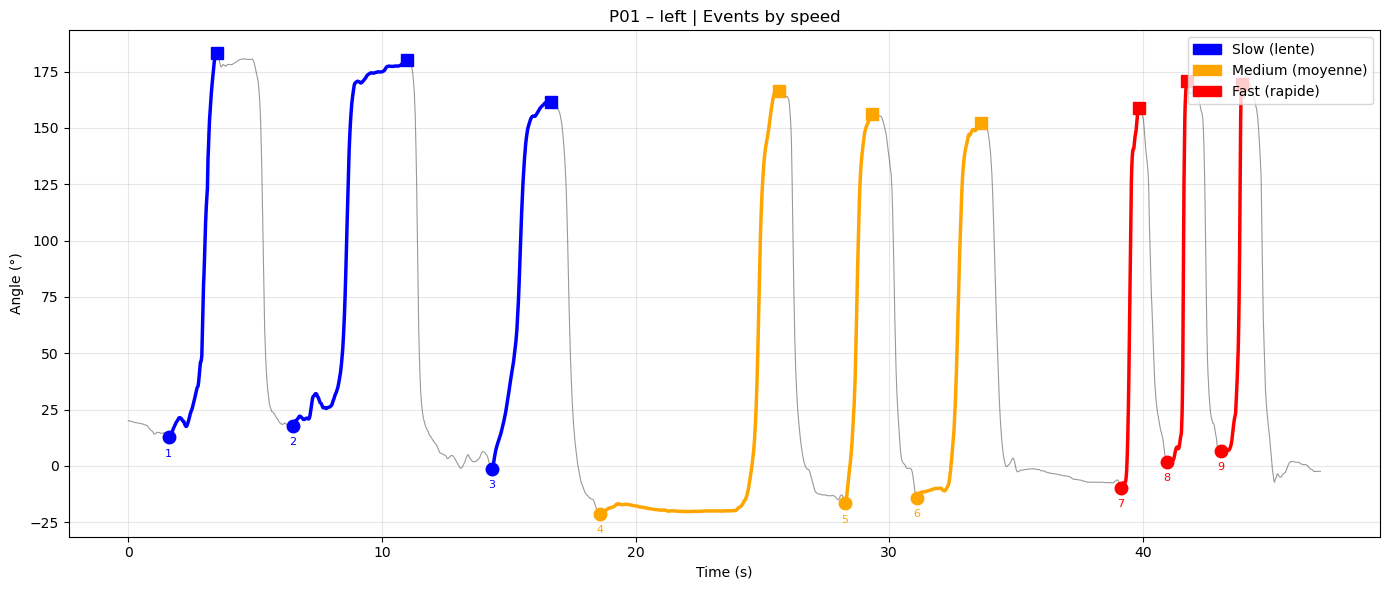


STATISTIQUES :

LENTE (n=3):
  Durée moyenne     : 2.91 s
  Amplitude moyenne : 165.2°
  Vitesse moyenne   : 65.3 °/s

MOYENNE (n=3):
  Durée moyenne     : 3.54 s
  Amplitude moyenne : 175.6°
  Vitesse moyenne   : 85.4 °/s

RAPIDE (n=3):
  Durée moyenne     : 0.78 s
  Amplitude moyenne : 166.9°
  Vitesse moyenne   : 215.1 °/s


In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.signal import butter, filtfilt, find_peaks

# ==========================================================
# PARAMETERS
# ==========================================================
N_MAX                  = 9
N_MIN                  = 10
MIN_PROM               = 15
MIN_DIST_SEC           = 1.5
FILTER_CUTOFF          = 10

# --- Kinetic onset parameters ---
VELOCITY_ONSET_THRESH  = 20.0   # °/s – threshold defining the low-velocity zone
                                 # in which the true angle minimum is searched.
                                 # Increase (e.g. 30) if onsets are too late,
                                 # decrease (e.g. 10) if still too early.
VELOCITY_SMOOTH_WINDOW = 15     # samples – moving-average window for velocity
                                 # smoothing before thresholding.

# ==========================================================
# LOW-PASS FILTER
# ==========================================================
def butter_lowpass_filter(signal, cutoff, fs, order=4):
    """Apply a zero-phase Butterworth low-pass filter to the signal."""
    nyq        = 0.5 * fs
    normal_cut = min(cutoff / nyq, 0.99)
    b, a       = butter(order, normal_cut, btype='low')
    return filtfilt(b, a, signal)

# ==========================================================
# SMOOTH VELOCITY
# ==========================================================
def compute_velocity(signal_f, fs, window=VELOCITY_SMOOTH_WINDOW):
    """
    Compute smoothed absolute angular velocity (°/s).
    Central-difference gradient followed by uniform moving-average.
    """
    raw_vel  = np.gradient(signal_f, 1.0 / fs)
    kernel   = np.ones(window) / window
    velocity = np.convolve(np.abs(raw_vel), kernel, mode='same')
    return velocity

# ==========================================================
# CORE FUNCTION: kinetic zone + angle argmin (fused)
# ==========================================================
def find_minimum_in_kinetic_zone(signal_f, velocity,
                                  search_start, search_end):
    """
    Find the true flexion minimum inside a search window using a
    two-step kinetic + geometric criterion.

    Step 1 – kinetic filter:
        Keep only samples where |dθ/dt| < VELOCITY_ONSET_THRESH.
        These form the 'low-velocity zone' (rest, deceleration end).

    Step 2 – angle argmin:
        Among the low-velocity samples, return the one with the
        smallest angle value → the deepest flexion point that is
        simultaneously kinetically valid.

    This fusion ensures the detected minimum is:
      • NOT in a high-velocity movement phase (kinetic criterion)
      • The geometrically correct angle minimum (argmin criterion)

    Fallback: if no sample passes the kinetic filter, use plain argmin.

    Parameters
    ----------
    signal_f     : np.ndarray – filtered angle signal (°)
    velocity     : np.ndarray – smoothed |dθ/dt| (°/s)
    search_start : int        – start index of search window
    search_end   : int        – end index of search window

    Returns
    -------
    int : absolute sample index of the detected minimum
    """
    seg_angle    = signal_f[search_start:search_end]
    seg_vel      = velocity[search_start:search_end]
    low_vel_mask = seg_vel < VELOCITY_ONSET_THRESH

    if not np.any(low_vel_mask):
        # Fallback: no low-velocity sample found
        return search_start + int(np.argmin(seg_angle))

    # Mask high-velocity samples with +inf so argmin ignores them
    masked_angle = seg_angle.copy().astype(float)
    masked_angle[~low_vel_mask] = np.inf

    return search_start + int(np.argmin(masked_angle))

# ==========================================================
# EVENT DETECTION
# ==========================================================
def detect_clean_events(df_angles):
    """
    Detect extension maxima and flexion minima.

    Minima are located using the kinetic+geometric fusion:
      for each inter-peak window, the minimum angle sample whose
      local velocity is below VELOCITY_ONSET_THRESH is returned.

    Returns
    -------
    minima   : np.ndarray – onset indices (angle minima in low-vel zones)
    raw_max  : np.ndarray – extension peak indices
    signal_f : np.ndarray – filtered angle
    velocity : np.ndarray – smoothed velocity
    """
    time     = df_angles["time"].values
    angle    = df_angles["angle"].values
    fs       = 1.0 / np.mean(np.diff(time))

    signal_f = butter_lowpass_filter(angle, FILTER_CUTOFF, fs)
    velocity = compute_velocity(signal_f, fs)

    dist_samples = int(fs * MIN_DIST_SEC)
    raw_max, _   = find_peaks(signal_f,
                               distance=dist_samples,
                               prominence=MIN_PROM)
    if len(raw_max) > N_MAX:
        idx     = np.argsort(signal_f[raw_max])[::-1]
        raw_max = raw_max[idx[:N_MAX]]
    raw_max = np.sort(raw_max)

    minima = []
    if len(raw_max) == 0:
        return np.array([], dtype=int), raw_max, signal_f, velocity

    # Before first peak
    minima.append(find_minimum_in_kinetic_zone(
        signal_f, velocity, 0, raw_max[0]))

    # Between consecutive peaks
    for i in range(len(raw_max) - 1):
        left, right = raw_max[i], raw_max[i + 1]
        if right - left > 5:
            minima.append(find_minimum_in_kinetic_zone(
                signal_f, velocity, left, right))

    # After last peak
    last_peak = raw_max[-1]
    if len(signal_f) - last_peak > 5:
        minima.append(find_minimum_in_kinetic_zone(
            signal_f, velocity, last_peak, len(signal_f)))

    minima = np.unique(np.array(minima, dtype=int))
    if len(minima) > N_MIN:
        minima = minima[:N_MIN]
    elif 0 < len(minima) < N_MIN:
        minima = np.pad(minima, (0, N_MIN - len(minima)), mode='edge')

    return minima, raw_max, signal_f, velocity

# ==========================================================
# PLOT + STORE  — single fused figure (angle + velocity)
# ==========================================================
def plot_and_store(df_angles, minima, maxima, signal_f, velocity,
                   patient_name, side, events_results):
    """
    Store results and display a two-panel verification figure.

    Top panel   : filtered angle signal
                  green dots = flexion minima (detected onsets)
                  red dots   = extension maxima
    Bottom panel: smoothed velocity with threshold line
                  green zones = low-velocity areas where search is active
                  green dots  = velocity VALUE at each detected minimum
                                (should all sit below the red dashed line)

    Both panels share the x-axis so you can verify that each green dot
    in the top panel aligns with a green zone in the bottom panel.
    """
    events_results.setdefault(patient_name, {})
    events_results[patient_name][side] = {
        "angles"          : df_angles,
        "signal_filtered" : signal_f,
        "peaks_flexion"   : minima,
        "peaks_extension" : maxima,
        "velocity"        : velocity
    }

    time = df_angles["time"].values

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                                    gridspec_kw={'height_ratios': [2, 1]})

    # ---- Top: angle ----
    ax1.plot(time, signal_f, color='steelblue', linewidth=1.2,
             label='Filtered angle')
    if len(minima) > 0:
        ax1.plot(time[minima], signal_f[minima], 'go',
                 ms=10, zorder=4,
                 label='Flexion minimum (onset)')
    if len(maxima) > 0:
        ax1.plot(time[maxima], signal_f[maxima], 'ro',
                 ms=10, zorder=4,
                 label='Full extension (max)')

    # Annotate each minimum with its event number
    for j, m in enumerate(minima):
        ax1.annotate(str(j + 1),
                     xy=(time[m], signal_f[m]),
                     xytext=(0, -14), textcoords='offset points',
                     ha='center', fontsize=7, color='darkgreen')

    ax1.set_ylabel('Angle (°)', fontsize=11)
    ax1.set_title(f'{patient_name} – {side}  '
                  f'[Kinetic onset, thr={VELOCITY_ONSET_THRESH} °/s]',
                  fontsize=12)
    ax1.legend(loc='upper right', fontsize=9)
    ax1.grid(True, alpha=0.3)

    # ---- Bottom: velocity ----
    ax2.plot(time, velocity, color='darkorange', linewidth=1.0,
             label='|Angular velocity| (°/s)')
    ax2.axhline(y=VELOCITY_ONSET_THRESH, color='red',
                linestyle='--', linewidth=1.4,
                label=f'Threshold ({VELOCITY_ONSET_THRESH} °/s)')
    ax2.fill_between(time, 0, velocity,
                     where=(velocity < VELOCITY_ONSET_THRESH),
                     alpha=0.25, color='green',
                     label='Low-vel zone (search active)')
    if len(minima) > 0:
        ax2.plot(time[minima], velocity[minima], 'go',
                 ms=10, zorder=4,
                 label='Velocity at onset (must be below threshold)')

    ax2.set_ylabel('Angular velocity (°/s)', fontsize=11)
    ax2.set_xlabel('Time (s)', fontsize=11)
    ax2.legend(loc='upper right', fontsize=9)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# ==========================================================
# MULTI-PATIENT DETECTION LOOP
# ==========================================================
events_results = {}

for patient_name, pdata in results.items():
    for side, data in pdata.items():

        print(f"\n=== DETECTION : {patient_name} | {side.upper()} ===")

        df       = data["wrist"]
        baseline = data["baseline"]["wrist"]

        df_angles = quaternion_to_angle_y_calibrated(
            df, baseline, baseline_deg=20)

        minima, maxima, signal_f, velocity = detect_clean_events(df_angles)

        plot_and_store(df_angles, minima, maxima, signal_f, velocity,
                       patient_name, side, events_results)

# ==========================================================
# EVENTS ANALYSIS
# ==========================================================
all_events_summary = {}

for patient_name in events_results:
    all_events_summary[patient_name] = {}

    for side in events_results[patient_name]:

        print(f"\n===== EVENTS: {patient_name} | {side.upper()} =====")

        data            = events_results[patient_name][side]
        df_angles       = data["angles"]
        peaks_flexion   = data["peaks_flexion"]
        peaks_extension = data["peaks_extension"]
        signal          = df_angles["angle"].values
        time            = df_angles["time"].values

        events = []

        if len(peaks_flexion) < 2 or len(peaks_extension) == 0:
            print("⚠️  Not enough peaks to build events.")
            continue

        n_events = min(len(peaks_extension), len(peaks_flexion) - 1)

        for i in range(n_events):
            min_idx     = peaks_flexion[i]
            max_idx     = peaks_extension[i]
            t_start     = time[min_idx]
            t_end       = time[max_idx]
            duration    = t_end - t_start
            angle_start = signal[min_idx]
            angle_end   = signal[max_idx]
            amplitude   = angle_end - angle_start
            velocity_ev = amplitude / duration if duration > 0 else 0

            events.append({
                'event_id'    : i + 1,
                'min_idx'     : min_idx,
                'max_idx'     : max_idx,
                't_start'     : t_start,
                't_end'       : t_end,
                'duration'    : duration,
                'angle_start' : angle_start,
                'angle_end'   : angle_end,
                'amplitude'   : amplitude,
                'velocity'    : velocity_ev
            })

        speed_labels = ['lente'] * 3 + ['moyenne'] * 3 + ['rapide'] * 3
        for i, event in enumerate(events):
            event['speed_category'] = (speed_labels[i]
                                       if i < len(speed_labels) else 'extra')

        df_events = pd.DataFrame(events)
        all_events_summary[patient_name][side] = df_events

        # ------ TABLE ------
        print("\n" + "=" * 60)
        print(f"TABLE – {patient_name} | {side}")
        print("=" * 60)
        if not df_events.empty:
            print(df_events[['event_id', 'speed_category',
                              't_start', 't_end', 'duration',
                              'amplitude', 'velocity']].to_string(index=False))

        # ------ EVENTS PLOT ------
        colors_speed = {
            'lente'  : 'blue',
            'moyenne': 'orange',
            'rapide' : 'red',
            'extra'  : 'gray'
        }

        fig, ax = plt.subplots(figsize=(14, 6))
        ax.plot(time, signal, 'k-', linewidth=0.8, alpha=0.4,
                label='Raw angle')

        for event in events:
            color     = colors_speed[event['speed_category']]
            idx_range = np.arange(event['min_idx'], event['max_idx'] + 1)
            ax.plot(time[idx_range], signal[idx_range],
                    color=color, linewidth=2.5)
            ax.plot(time[event['min_idx']], signal[event['min_idx']],
                    'o', color=color, ms=9)
            ax.plot(time[event['max_idx']], signal[event['max_idx']],
                    's', color=color, ms=9)
            # Label each event
            ax.annotate(str(event['event_id']),
                        xy=(time[event['min_idx']], signal[event['min_idx']]),
                        xytext=(0, -14), textcoords='offset points',
                        ha='center', fontsize=8, color=color)

        legend_handles = [
            Patch(color='blue',   label='Slow (lente)'),
            Patch(color='orange', label='Medium (moyenne)'),
            Patch(color='red',    label='Fast (rapide)'),
        ]
        ax.legend(handles=legend_handles, loc='upper right')
        ax.set_title(f"{patient_name} – {side} | Events by speed")
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Angle (°)")
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

        # ------ STATS ------
        print("\nSTATISTIQUES :")
        for cat in ['lente', 'moyenne', 'rapide']:
            subset = df_events[df_events['speed_category'] == cat]
            if len(subset) == 0:
                continue
            print(f"\n{cat.upper()} (n={len(subset)}):")
            print(f"  Durée moyenne     : {subset['duration'].mean():.2f} s")
            print(f"  Amplitude moyenne : {subset['amplitude'].mean():.1f}°")
            print(f"  Vitesse moyenne   : {subset['velocity'].mean():.1f} °/s")


=== DETECTION : P01 | RIGHT ===


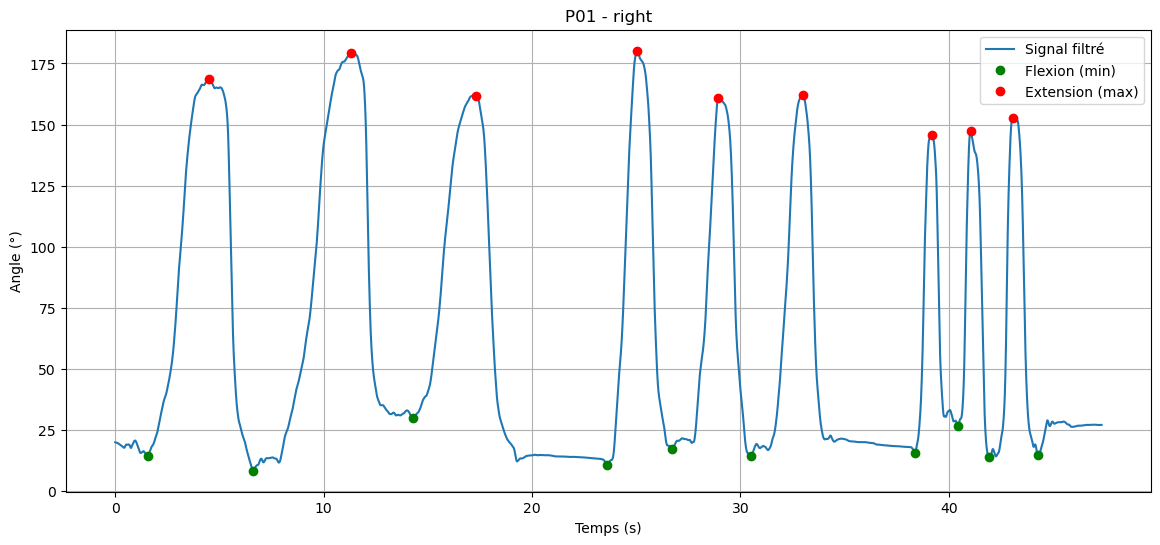


=== DETECTION : P01 | LEFT ===


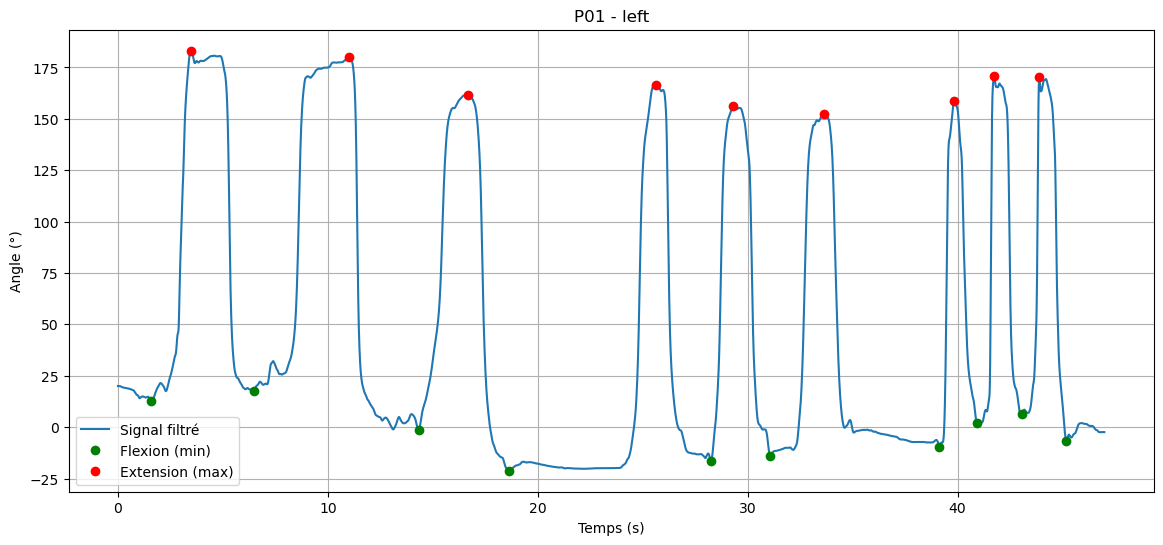


===== EVENTS: P01 | RIGHT =====
   event_id  t_start   t_end  duration   amplitude    velocity
0         1   1.5560   4.492    2.9360  154.475865   83.173312
1         2   6.6159  11.296    4.6801  170.893314   58.038610
2         3  14.2760  17.312    3.0360  131.851319   72.071445
3         4  23.6039  25.052    1.4481  169.695196  169.134192
4         5  26.7080  28.936    2.2280  143.397307   52.639920
5         6  30.5160  33.000    2.4840  147.501872   76.376574
6         7  38.3760  39.184    0.8080  130.482064  270.066963
7         8  40.4440  41.048    0.6040  120.594737  295.198419
8         9  41.9120  43.068    1.1560  138.832630  102.489546

===== EVENTS: P01 | LEFT =====
   event_id  t_start    t_end  duration   amplitude    velocity
0         1   1.5960   3.4800    1.8840  170.401217   76.419029
1         2   6.4760  10.9840    4.5080  162.395935   65.238402
2         3  14.3240  16.6640    2.3400  162.773344  111.041886
3         4  18.6159  25.6440    7.0281  187.5935

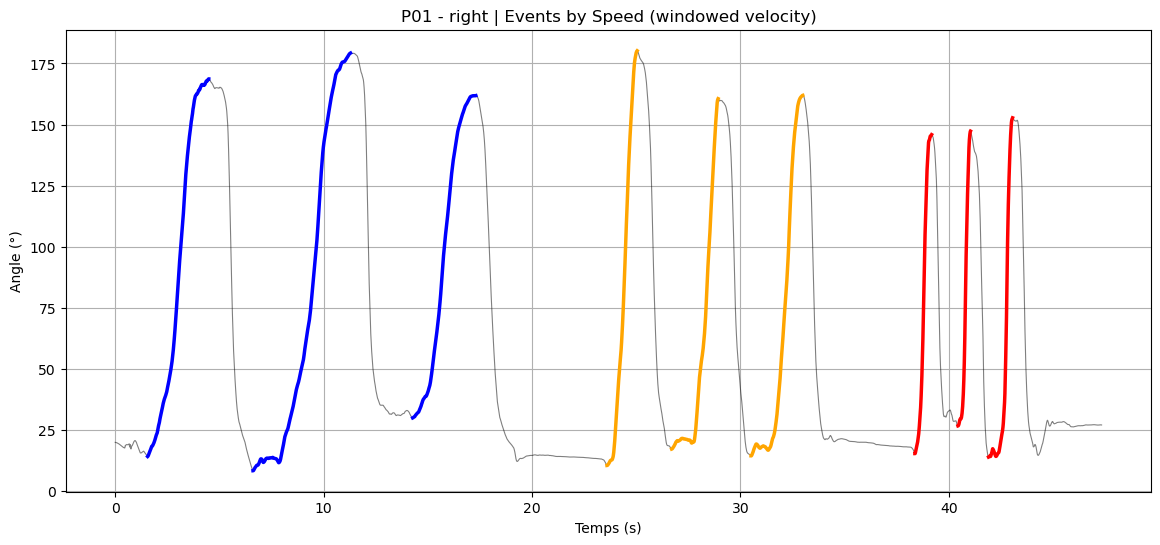


STATISTIQUES :

LENTE (n=3):
  Durée moyenne     : 3.55 s
  Amplitude moyenne : 152.4°
  Vitesse moyenne   : 71.1 °/s

MOYENNE (n=3):
  Durée moyenne     : 2.05 s
  Amplitude moyenne : 153.5°
  Vitesse moyenne   : 99.4 °/s

RAPIDE (n=3):
  Durée moyenne     : 0.86 s
  Amplitude moyenne : 130.0°
  Vitesse moyenne   : 222.6 °/s

TABLE - P01 | left
 event_id speed_category  t_start   t_end  duration  amplitude   velocity
        1          lente   1.5960  3.4800    1.8840 170.401217  76.419029
        2          lente   6.4760 10.9840    4.5080 162.395935  65.238402
        3          lente  14.3240 16.6640    2.3400 162.773344 111.041886
        4        moyenne  18.6159 25.6440    7.0281 187.593545  -0.351347
        5        moyenne  28.2519 29.3040    1.0521 172.604701 266.242436
        6        moyenne  31.0800 33.6280    2.5480 166.497435 117.538730
        7         rapide  39.1400 39.8480    0.7080 168.638220 424.625570
        8         rapide  40.9360 41.7399    0.8039 169.022

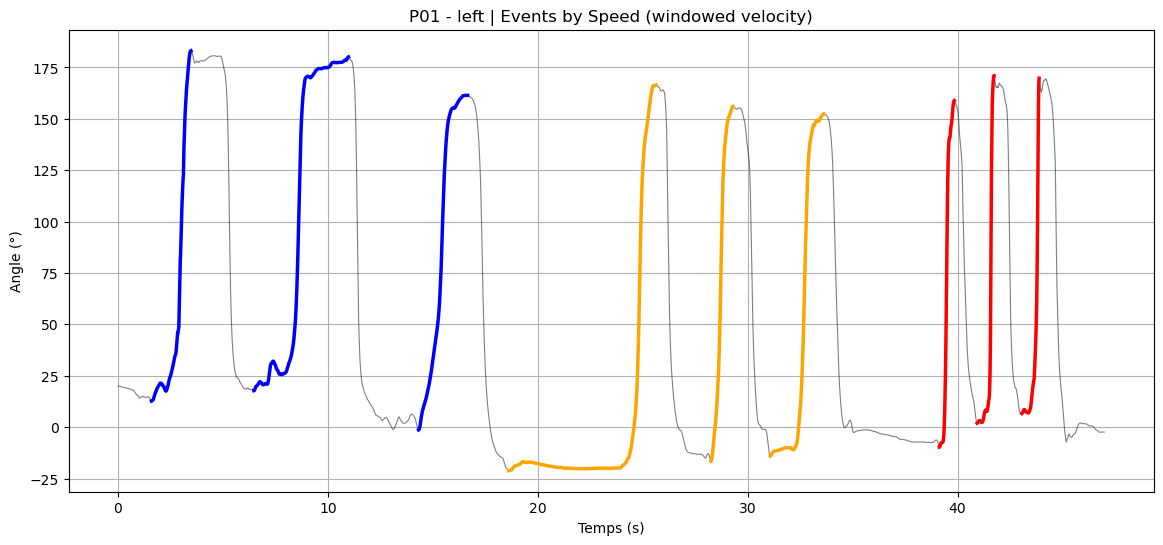


STATISTIQUES :

LENTE (n=3):
  Durée moyenne     : 2.91 s
  Amplitude moyenne : 165.2°
  Vitesse moyenne   : 84.2 °/s

MOYENNE (n=3):
  Durée moyenne     : 3.54 s
  Amplitude moyenne : 175.6°
  Vitesse moyenne   : 127.8 °/s

RAPIDE (n=3):
  Durée moyenne     : 0.78 s
  Amplitude moyenne : 166.9°
  Vitesse moyenne   : 176.1 °/s


In [29]:
###  Essais en prenant uniquement la vitesse sur une fenêtre temporal centrale 


# import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks

# ==========================================================
# PARAMÈTRES GÉNÉRAUX
# ==========================================================
N_MAX = 9
N_MIN = 10
MIN_PROM = 15
MIN_DIST_SEC = 1.5
FILTER_CUTOFF = 10

# ==========================================================
# FILTRE PASSE-BAS
# ==========================================================
def butter_lowpass_filter(signal, cutoff, fs, order=4):
    nyq = 0.5 * fs
    normal_cut = min(cutoff / nyq, 0.99)
    b, a = butter(order, normal_cut, btype='low')
    return filtfilt(b, a, signal)

# ==========================================================
# CALCUL DE VITESSE MOYENNE SUR FENÊTRE CENTRALE
# ==========================================================
def compute_mean_velocity_window(df_angles, min_idx, max_idx, window_ratio=0.2):
    """
    Calcule la vitesse moyenne sur la partie centrale du mouvement
    (en excluant window_ratio aux extrémités).
    """
    time_seg = df_angles["time"].iloc[min_idx:max_idx + 1].values
    angle_seg = df_angles["angle"].iloc[min_idx:max_idx + 1].values

    if len(time_seg) < 5:
        return np.nan

    velocity = np.gradient(angle_seg, time_seg)
    n = len(velocity)
    start_win = int(n * window_ratio)
    end_win = int(n * (1 - window_ratio))

    if end_win <= start_win:
        return np.nan

    velocity_core = velocity[start_win:end_win]
    mean_velocity_window = np.mean(velocity_core)
    return mean_velocity_window

# ==========================================================
# DÉTECTION DES ÉVÉNEMENTS
# ==========================================================
def detect_clean_events(df_angles):
    time = df_angles["time"].values
    angle = df_angles["angle"].values
    fs = 1 / np.mean(np.diff(time))

    # --- Filtrage
    signal_f = butter_lowpass_filter(angle, FILTER_CUTOFF, fs)

    # --- Détection des maxima (pics d’extension)
    dist_samples = int(fs * MIN_DIST_SEC)
    raw_max, _ = find_peaks(signal_f, distance=dist_samples, prominence=MIN_PROM)
    if len(raw_max) > N_MAX:
        idx = np.argsort(signal_f[raw_max])[::-1]
        raw_max = raw_max[idx[:N_MAX]]
    raw_max = np.sort(raw_max)

    # --- Détection basique des minima (avant, entre, après les max)
    minima = []
    if len(raw_max) > 0:
        first_max = raw_max[0]
        start = int(max(0, first_max - 3.5 * fs))
        segment = signal_f[start:first_max]
        if len(segment) > 5:
            minima.append(start + np.argmin(segment))
    for i in range(len(raw_max) - 1):
        left = raw_max[i]
        right = raw_max[i + 1]
        segment = signal_f[left:right]
        if len(segment) > 5:
            minima.append(left + np.argmin(segment))
    if len(raw_max) > 0:
        last_max = raw_max[-1]
        segment = signal_f[last_max:]
        if len(segment) > 5:
            minima.append(last_max + np.argmin(segment))

    minima = np.array(minima, dtype=int)
    minima = np.unique(minima)
    if len(minima) > N_MIN:
        minima = minima[:N_MIN]
    elif len(minima) < N_MIN and len(minima) > 0:
        minima = np.pad(minima, (0, N_MIN - len(minima)), mode='edge')

    return minima, raw_max, signal_f

# ==========================================================
# PLOT + STOCKAGE
# ==========================================================
def plot_and_store(df_angles, minima, maxima, signal_f, patient_name, side, events_results):
    events_results.setdefault(patient_name, {})
    events_results[patient_name][side] = {
        "angles": df_angles,
        "signal_filtered": signal_f,
        "peaks_flexion": minima,
        "peaks_extension": maxima
    }

    time = df_angles["time"].values
    plt.figure(figsize=(14, 6))
    plt.plot(time, signal_f, label="Signal filtré")
    if len(minima) > 0:
        plt.plot(time[minima], signal_f[minima], "go", label="Flexion (min)")
    if len(maxima) > 0:
        plt.plot(time[maxima], signal_f[maxima], "ro", label="Extension (max)")
    plt.title(f"{patient_name} - {side}")
    plt.xlabel("Temps (s)")
    plt.ylabel("Angle (°)")
    plt.legend()
    plt.grid()
    plt.show()

# ==========================================================
# DÉTECTION MULTI-PATIENTS
# ==========================================================
events_results = {}

for patient_name, pdata in results.items():
    for side, data in pdata.items():
        print(f"\n=== DETECTION : {patient_name} | {side.upper()} ===")
        df = data["wrist"]
        baseline = data["baseline"]["wrist"]
        df_angles = quaternion_to_angle_y_calibrated(df, baseline, baseline_deg=20)
        minima, maxima, signal_f = detect_clean_events(df_angles)
        plot_and_store(df_angles, minima, maxima, signal_f, patient_name, side, events_results)

# ==========================================================
# ANALYSE DES ÉVÉNEMENTS (calcul vitesse moyenne sur fenêtre)
# ==========================================================
all_events_summary = {}

for patient_name in events_results:
    all_events_summary[patient_name] = {}

    for side in events_results[patient_name]:
        print(f"\n===== EVENTS: {patient_name} | {side.upper()} =====")
        data = events_results[patient_name][side]
        df_angles = data["angles"]
        peaks_flexion = data["peaks_flexion"]
        peaks_extension = data["peaks_extension"]
        signal = df_angles["angle"].values
        time = df_angles["time"].values

        events = []
        n_events = min(len(peaks_extension), len(peaks_flexion) - 1)

        for i in range(n_events):
            min_idx = peaks_flexion[i]
            max_idx = peaks_extension[i]
            t_start = time[min_idx]
            t_end = time[max_idx]
            duration = t_end - t_start
            amplitude = signal[max_idx] - signal[min_idx]

            # ---- NOUVEAU CALCUL DE VITESSE (fenêtre centrale)
            mean_vel_window = compute_mean_velocity_window(df_angles, min_idx, max_idx, window_ratio=0.25)
            velocity = mean_vel_window if not np.isnan(mean_vel_window) else amplitude / duration

            events.append({
                "event_id": i + 1,
                "t_start": t_start,
                "t_end": t_end,
                "duration": duration,
                "amplitude": amplitude,
                "velocity": velocity
            })

        df_events = pd.DataFrame(events)
        all_events_summary[patient_name][side] = df_events
        print(df_events)

# ==========================================================
# EVENTS ANALYSIS (MULTI-PATIENTS)
# ==========================================================
for patient_name in events_results:
    print(f"\n===== EVENTS: {patient_name} =====")
    for side in events_results[patient_name]:
        data = events_results[patient_name][side]
        df_angles = data["angles"]
        peaks_flexion = data["peaks_flexion"]
        peaks_extension = data["peaks_extension"]
        signal = df_angles["angle"].values
        time = df_angles["time"].values
        df_events = all_events_summary[patient_name][side]

        if df_events.empty:
            continue

        # Classification
        speed_labels = ['lente'] * 3 + ['moyenne'] * 3 + ['rapide'] * 3
        df_events = df_events.copy()
        df_events["speed_category"] = [
            speed_labels[i] if i < len(speed_labels) else "extra"
            for i in range(len(df_events))
        ]

        # TABLE
        print("\n" + "=" * 60)
        print(f"TABLE - {patient_name} | {side}")
        print("=" * 60)
        print(df_events[['event_id', 'speed_category',
                         't_start', 't_end',
                         'duration', 'amplitude', 'velocity']].to_string(index=False))

        # PLOT
        colors_speed = {'lente': 'blue', 'moyenne': 'orange', 'rapide': 'red', 'extra': 'gray'}
        plt.figure(figsize=(14,6))
        plt.plot(time, signal, 'k-', linewidth=0.8, alpha=0.5)
        for _, ev in df_events.iterrows():
            color = colors_speed[ev['speed_category']]
            idx_range = np.arange(int((ev.t_start - time[0]) / np.mean(np.diff(time))),
                                  int((ev.t_end - time[0]) / np.mean(np.diff(time))))
            plt.plot(time[idx_range], signal[idx_range], color=color, linewidth=2.5)
        plt.title(f"{patient_name} - {side} | Events by Speed (windowed velocity)")
        plt.xlabel("Temps (s)")
        plt.ylabel("Angle (°)")
        plt.grid(True)
        plt.show()

        # STATISTIQUES
        print("\nSTATISTIQUES :")
        for cat in ['lente', 'moyenne', 'rapide']:
            subset = df_events[df_events['speed_category'] == cat]
            if len(subset) == 0:
                continue
            print(f"\n{cat.upper()} (n={len(subset)}):")
            print(f"  Durée moyenne     : {subset['duration'].mean():.2f} s")
            print(f"  Amplitude moyenne : {subset['amplitude'].mean():.1f}°")
            print(f"  Vitesse moyenne   : {subset['velocity'].mean():.1f} °/s")